In [1]:
!pip install yfinance scipy pandas numpy matplotlib requests lxml html5lib beautifulsoup4 -q

print("✅ All dependencies installed.")

✅ All dependencies installed.


In [2]:
# All tunable parameters live in CONFIG.
# Change values here and re-run downstream blocks

import io
import warnings
import requests
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams["figure.figsize"]    = (13, 6)
plt.rcParams["axes.grid"]         = True
plt.rcParams["grid.alpha"]        = 0.3
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# ── Chart colour palette ──────────────────────────────────────
NAVY  = "#1B2A4A"
RED   = "#C0392B"
GREEN = "#1A7A4A"
BLUE  = "#2471A3"
GRAY  = "#7F8C8D"

CONFIG = {
    # ── Backtest window ─────────────────────────────────────────────
    "DATA_START"       : "2020-01-01",   # Pull from here (buffer for lookback)
    "BACKTEST_START"   : "2022-01-03",   # First iadi reconstitution date
    "BASE_VALUE"       : 1000.0,

    # ── Revenue proxy (keyword match on longBusinessSummary) ────────
    "REVENUE_KEYWORDS" : [
        "defence", "defense", "military", "government contract",
        "aerospace", "weapon", "missile", "radar", "cybersecurity",
        "electronic warfare", "autonomous", "drone", "surveillance",
        "fighter", "naval", "warship", "satellite", "munition",
        "ballistic", "counter-drone", "intelligence",
    ],
    "MIN_KEYWORDS"     : 2,             # Stock needs >= 2 keywords to pass

    # ── Liquidity (native currency) ─────────────────────────────────
    "ADTV_USD_MIN"     : 10_000_000,    # USD 10M
    "ADTV_INR_MIN"     : 150_000_000,   # INR 15 Cr = 150M
    "ADTV_LOOKBACK"    : 63,            # 63 trading days = ~3 months
    "BUFFER_MULT"      : 0.80,          # Existing constituents: 80% threshold

    # ── Market cap (native currency) ────────────────────────────────
    "MCAP_USD_MIN"     : 500_000_000,   # USD 500M
    "MCAP_INR_MIN"     : 10_000_000_000,# INR 1000 Cr = 10B

    # ── Optimiser ───────────────────────────────────────────────────
    "VOL_LOOKBACK"     : 126,           # ~6 months rolling window
    "WEIGHT_FLOOR"     : 0.02,          # 2% minimum per stock
    "WEIGHT_CAP"       : 0.10,          # 10% maximum per stock
    "RIDGE_LAMBDA"     : 1e-6,          # Covariance regularisation
    "MIN_STOCKS"       : 10,            # Minimum viable portfolio
    "MIN_HIST_DAYS"    : 60,            # Minimum overlap days for cov matrix

    # ── Rebalancing calendar ────────────────────────────────────────
    "RECON_MONTHS"     : [1,7],           # Semi-Annual: January July
    "REBAL_MONTHS"     : [3, 6, 9, 12], # Quarterly: Mar Jun Sep Dec

    # ── Risk-free rate (INR index → Indian 10-yr G-Sec) ────────────
    "RISK_FREE"        : 0.065,         # 6.5%

    # ── Benchmark tickers ───────────────────────────────────────────
    "TICKER_ITA"       : "ITA",         # iShares US Aerospace & Defence ETF
    "TICKER_NIFTY50"   : "^NSEI",       # Nifty 50 (fallback India leg)
    "TICKER_USDINR"    : "USDINR=X",    # USD/INR daily FX rate
}

print("✅ Configuration locked.")
print(f"   Backtest  : {CONFIG['BACKTEST_START']} → today")
print(f"   Weights   : floor={CONFIG['WEIGHT_FLOOR']*100:.0f}%  "
      f"cap={CONFIG['WEIGHT_CAP']*100:.0f}%")
print(f"   Lookback  : {CONFIG['VOL_LOOKBACK']} trading days")
print(f"   Risk-free : {CONFIG['RISK_FREE']*100:.1f}% (INR G-Sec)")


✅ Configuration locked.
   Backtest  : 2022-01-03 → today
   Weights   : floor=2%  cap=10%
   Lookback  : 126 trading days
   Risk-free : 6.5% (INR G-Sec)


In [3]:
# ============================================================
# UNIVERSE CONSTRUCTION (2 Sources)
# ============================================================
# Source 1 : NSE EQUITY_L.csv  → keyword match on company name
# Source 2 : Supplementary US pure-plays (curated, not in S&P500)
#
# Wikipedia S&P 500 source was dropped — the GICS sub-industry
# filter was pulling in too many diversified industrials with
# minimal defence revenue. NSE + curated US list gives a
# tighter, more thematic starting universe.
#
# Both sources merged, deduplicated → passed to Block 03
# for yfinance validation and revenue keyword filtering.

# ── Source 2: Curated US pure-plays ─────────────────────────────────────────
# Covers the full spectrum: primes, autonomy, cyber, space-adjacent
SUPPLEMENTARY_US = [
    # Large primes
    "LMT", "RTX", "NOC", "GD", "BA", "LHX", "HII",
    # Mid-tier / high-growth
    "KTOS", "AVAV", "AXON", "BWXT", "MRCY", "CW",
    "HEI", "TDG", "TXT", "LDOS", "SAIC", "CACI", "BAH",
    # AI / autonomy / software
    "PLTR", "RCAT", "ATRO", "VSEC",
    # Cyber / EW
    "FTNT", "CRWD", "PANW",
]

# ── Source 1: NSE EQUITY_L.csv ───────────────────────────────────────────────
NSE_DEFENCE_KEYWORDS = [
    "DEFENCE", "DEFENSE", "AEROSPACE", "AERO", "AIRCRAFT",
    "MISSILE", "RADAR", "NAVAL", "WARSHIP", "HELICOPTER",
    "MUNITION", "BALLISTIC", "ELECTRONICS", "SHIPBUILDER",
]

# Cached India fallback — used if NSE live fetch fails or is blocked
NSE_CACHED_FALLBACK = [
    "HAL.NS", "BEL.NS", "BEML.NS", "MAZDOCK.NS", "GRSE.NS",
    "COCHINSHIP.NS", "PARAS.NS", "DATAPATTNS.NS", "MTARTECH.NS",
    "ZENTEC.NS", "ASTRAMICRO.NS", "MIDHANI.NS",
    "DCXINDIA.NS", "IDEAFORGE.NS", "UNIMECH.NS",
    "BDL.NS", "SOLARINDS.NS",
    "CYIENTDLM.NS", "BHARATFORG.NS",
]

def fetch_nse_defence():
    """
    Pull NSE EQUITY_L.csv with browser User-Agent.
    Filter rows where company name contains any NSE_DEFENCE_KEYWORDS.
    Returns list of .NS tickers.
    Falls back to cached list if request fails.
    """
    url = "https://nsearchives.nseindia.com/content/equities/EQUITY_L.csv"
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Referer": "https://www.nseindia.com/",
    }
    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        df.columns = [c.strip() for c in df.columns]

        name_col = ("NAME OF COMPANY" if "NAME OF COMPANY" in df.columns
                    else df.columns[1])
        sym_col  = ("SYMBOL" if "SYMBOL" in df.columns
                    else df.columns[0])

        def has_keyword(name):
            nm = str(name).upper()
            return any(kw in nm for kw in NSE_DEFENCE_KEYWORDS)

        mask    = df[name_col].apply(has_keyword)
        tickers = (df.loc[mask, sym_col].str.strip() + ".NS").tolist()
        print(f"  [Source 1] NSE live CSV    : {len(tickers)} candidates")
        return tickers

    except Exception as e:
        print(f"  [Source 1] NSE fetch FAILED ({e}) — using cached fallback")
        return NSE_CACHED_FALLBACK


# ── Build merged universe ─────────────────────────────────────────────────────
print("Building candidate universe...")
print("-" * 55)

india_nse  = fetch_nse_defence()
us_extras  = SUPPLEMENTARY_US

# Union of NSE + curated US + cached India safety net
raw_universe = sorted(
    set(india_nse) | set(us_extras) | set(NSE_CACHED_FALLBACK)
)

n_us    = sum(1 for t in raw_universe if not t.endswith(".NS"))
n_india = sum(1 for t in raw_universe if     t.endswith(".NS"))

print("-" * 55)
print(f"  Merged raw candidates : {len(raw_universe)}")
print(f"    US tickers          : {n_us}")
print(f"    India (.NS) tickers : {n_india}")
print(f"\n  Sample US    : {[t for t in raw_universe if not t.endswith('.NS')][:6]}")
print(f"  Sample India : {[t for t in raw_universe if t.endswith('.NS')][:6]}")


Building candidate universe...
-------------------------------------------------------
  [Source 1] NSE live CSV    : 22 candidates
-------------------------------------------------------
  Merged raw candidates : 62
    US tickers          : 27
    India (.NS) tickers : 35

  Sample US    : ['ATRO', 'AVAV', 'AXON', 'BA', 'BAH', 'BWXT']
  Sample India : ['AEROENTER.NS', 'AEROFLEX.NS', 'AERONEU.NS', 'ASTRAMICRO.NS', 'BDL.NS', 'BEL.NS']


In [4]:
# ============================================================
# VALIDATE UNIVERSE VIA YFINANCE + TAG METADATA
# ============================================================
# For each raw candidate:
#   1. Fetch yfinance .info — confirm ticker is live
#   2. Apply revenue keyword proxy (>= MIN_KEYWORDS in business summary)
#      OR ticker is in FORCE_INCLUDE
#   3. Hard-exclude tickers in FORCE_EXCLUDE regardless of keywords
#   4. Tag: geography, exchange, sub-theme, marketCap
#
# Output: universe_df — validated, tagged candidate pool

# ── Manual overrides ─────────────────────────────────────────────────────────
FORCE_INCLUDE = {
    "PLTR"  : "Core US gov/defence contractor; sparse yfinance description",
    "AXON"  : "Law-enforcement tech; defence-adjacent; often miscategorised",
    "KTOS"  : "Pure-play defence autonomy; keyword-light yfinance description",
    "LDOS"  : "Major US defence IT integrator; keyword-light description",
    "SAIC"  : "Major US defence IT; description does not always hit threshold",
    "CACI"  : "Defence intelligence / cyber services; keyword-light",
    "BAH"   : "Booz Allen Hamilton — core US defence consultancy",
}

FORCE_EXCLUDE = {
    "FTNT"          : "Pure commercial cybersecurity; negligible govt/defence",
    "CRWD"          : "Pure commercial cybersecurity; negligible govt/defence",
    "PANW"          : "Pure commercial cybersecurity; negligible govt/defence",
    "BHARATFORG.NS" : "Auto forgings >60% revenue; defence <33% threshold",
    "BEML.NS"       : "Railway/mining dominant; defence segment <33%",
    "BHEL.NS"       : "Power equipment dominant; defence revenue minimal",
}

def keyword_score(text):
    if not isinstance(text, str):
        return 0
    t = text.lower()
    return sum(1 for kw in CONFIG["REVENUE_KEYWORDS"] if kw in t)

def classify_subtheme(text):
    if not isinstance(text, str):
        return "Defence Manufacturing"
    t = text.lower()
    if any(k in t for k in ["cyber", "electronic warfare", "endpoint",
                              "firewall", "network security", "encryption",
                              "signals intelligence"]):
        return "Cyber / EW"
    if any(k in t for k in ["autonomous", "drone", "unmanned",
                              "artificial intelligence", "machine learning",
                              "counter-drone", "swarm", "robotic"]):
        return "AI / Autonomous"
    return "Defence Manufacturing"

def validate_ticker(tkr):
    """
    Returns metadata dict if ticker passes all checks, else None.
    Check order:
      1. yfinance returns a valid price  (ticker is live)
      2. Not in FORCE_EXCLUDE           (hard stop)
      3. In FORCE_INCLUDE OR keyword_score >= MIN_KEYWORDS
    """
    try:
        info = yf.Ticker(tkr).info
        if not info:
            return None

        price = (info.get("regularMarketPrice")
                 or info.get("currentPrice")
                 or info.get("previousClose"))
        if not price or price == 0:
            return None

        if tkr in FORCE_EXCLUDE:
            return None

        summary = info.get("longBusinessSummary", "")
        score   = keyword_score(summary)

        if tkr not in FORCE_INCLUDE and score < CONFIG["MIN_KEYWORDS"]:
            return None

        is_india = tkr.endswith(".NS")
        return {
            "ticker"    : tkr,
            "name"      : str(info.get("longName", tkr))[:55],
            "geography" : "India" if is_india else "US",
            "exchange"  : "NSE"   if is_india else "NYSE/NASDAQ",
            "currency"  : "INR"   if is_india else "USD",
            "marketCap" : info.get("marketCap", np.nan),
            "industry"  : info.get("industry",  "Unknown"),
            "subtheme"  : classify_subtheme(summary),
            "kw_score"  : score,
            "forced_in" : tkr in FORCE_INCLUDE,
        }
    except Exception:
        return None

# ── Validate all raw candidates ──────────────────────────────────────────────
print(f"Validating {len(raw_universe)} candidates via yfinance ...")

validated_rows = []
failed_tickers = []

for i, tkr in enumerate(raw_universe, 1):
    row = validate_ticker(tkr)
    if row:
        validated_rows.append(row)
    else:
        failed_tickers.append(tkr)
    if i % 15 == 0 or i == len(raw_universe):
        print(f"  [{i:3d}/{len(raw_universe)}]  "
              f"passed={len(validated_rows)}  "
              f"dropped={len(failed_tickers)}")

# ── Build universe_df ────────────────────────────────────────────────────────
universe_df = pd.DataFrame(validated_rows).set_index("ticker")

n_us    = (universe_df["geography"] == "US").sum()
n_india = (universe_df["geography"] == "India").sum()

print("\n" + "=" * 60)
print(f"VALIDATED UNIVERSE: {len(universe_df)} tickers")
print(f"  US    : {n_us}")
print(f"  India : {n_india}")
print(f"  Split : {n_us/(n_us+n_india)*100:.0f}% US / "
      f"{n_india/(n_us+n_india)*100:.0f}% India")
print("=" * 60)

print("\nSub-theme breakdown:")
print(universe_df["subtheme"].value_counts().to_string())

print("\nForce-include applied:")
for t, r in FORCE_INCLUDE.items():
    if t in universe_df.index:
        print(f"  {t:20s}: {r}")

print("\nForce-exclude applied:")
for t, r in FORCE_EXCLUDE.items():
    print(f"  {t:20s}: {r}")

print("\nFull validated universe:")
display_cols = ["name", "geography", "subtheme", "industry", "forced_in"]
print(universe_df[display_cols].to_string())


Validating 62 candidates via yfinance ...
  [ 15/62]  passed=11  dropped=4
  [ 30/62]  passed=21  dropped=9
  [ 45/62]  passed=32  dropped=13
  [ 60/62]  passed=43  dropped=17
  [ 62/62]  passed=44  dropped=18

VALIDATED UNIVERSE: 44 tickers
  US    : 23
  India : 21
  Split : 52% US / 48% India

Sub-theme breakdown:
subtheme
Defence Manufacturing    17
Cyber / EW               14
AI / Autonomous          13

Force-include applied:
  PLTR                : Core US gov/defence contractor; sparse yfinance description
  AXON                : Law-enforcement tech; defence-adjacent; often miscategorised
  KTOS                : Pure-play defence autonomy; keyword-light yfinance description
  LDOS                : Major US defence IT integrator; keyword-light description
  SAIC                : Major US defence IT; description does not always hit threshold
  CACI                : Defence intelligence / cyber services; keyword-light
  BAH                 : Booz Allen Hamilton — core US defence 

In [5]:
# ============================================================
# BLOCK 04 — DATA INGESTION
# ============================================================
# Downloads TWO separate price matrices:
#
# A) iadi Universe + FX + ITA
#    All validated tickers + USDINR + ITA + Nifty50
#    Used for index construction and the ITA benchmark leg
#
# B) Nifty Defence Proxy Tickers (dedicated download)
#    All 20 Nifty Defence constituent tickers downloaded
#    INDEPENDENTLY of iadi eligibility filters.
#    Reason: Nifty Defence uses 10% revenue threshold vs
#    our 33% — some tickers are valid benchmark members
#    but not iadi members (e.g. BHARATFORG, SOLARINDS, BDL)
#
# Edge cases:
#   - Short gaps (<= 5 days): forward-filled
#   - Tickers with < VOL_LOOKBACK + 30 days before backtest: dropped
#   - Volume NaN: filled with 0
#   - USDINR gaps: forward-filled

# ── A) iadi Universe Download ────────────────────────────────────────────────
BENCHMARK_TICKERS = [
    CONFIG["TICKER_ITA"],
    CONFIG["TICKER_NIFTY50"],
    CONFIG["TICKER_USDINR"],
]

iadi_download_tickers = universe_df.index.tolist() + BENCHMARK_TICKERS

print("=" * 60)
print(f"A) Downloading iadi universe ({len(iadi_download_tickers)} tickers)...")
print("=" * 60)

raw_iadi = yf.download(
    iadi_download_tickers,
    start=CONFIG["DATA_START"],
    progress=True,
    auto_adjust=True,
    group_by="ticker",
    threads=True,
)

def extract_field(raw, tickers, field):
    out = {}
    for tkr in tickers:
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                s = raw[tkr][field]
            else:
                s = raw[field]
            if s.notna().sum() > 50:
                out[tkr] = s
        except (KeyError, AttributeError):
            continue
    return pd.DataFrame(out)

prices_raw_iadi  = extract_field(raw_iadi, iadi_download_tickers, "Close")
volumes_raw_iadi = extract_field(raw_iadi, iadi_download_tickers, "Volume")

prices_all  = prices_raw_iadi.ffill(limit=5)
volumes_all = volumes_raw_iadi.fillna(0)

# ── Drop tickers without enough history before backtest start ──────────────
backtest_ts   = pd.Timestamp(CONFIG["BACKTEST_START"])
min_days_need = CONFIG["VOL_LOOKBACK"] + 30

valid_universe_tickers = []
dropped = []

for t in universe_df.index:
    if t not in prices_all.columns:
        dropped.append((t, "not in download"))
        continue
    hist = prices_all[t].loc[:backtest_ts].notna().sum()
    if hist < min_days_need:
        dropped.append((t, f"only {hist} days before backtest start"))
    else:
        valid_universe_tickers.append(t)

universe_df      = universe_df.loc[valid_universe_tickers].copy()
prices_universe  = prices_all[valid_universe_tickers].copy()
volumes_universe = volumes_all[[t for t in valid_universe_tickers
                                if t in volumes_all.columns]].copy()
prices_bench     = prices_all[[t for t in BENCHMARK_TICKERS
                               if t in prices_all.columns]].copy()

# ── USDINR ───────────────────────────────────────────────────────────────────
if CONFIG["TICKER_USDINR"] in prices_all.columns:
    usdinr = prices_all[CONFIG["TICKER_USDINR"]].ffill().bfill()
else:
    usdinr = pd.Series(83.5, index=prices_all.index)
    print("⚠️  USDINR=X not available — using fixed rate 83.5 (fallback)")

print(f"\n✅ iadi universe download complete")
print(f"   Tickers kept    : {len(valid_universe_tickers)}")
print(f"   Tickers dropped : {len(dropped)}")
print(f"   Price matrix    : {prices_universe.shape}")
print(f"   USDINR range    : {usdinr.min():.2f} – {usdinr.max():.2f} "
      f"(latest: {usdinr.iloc[-1]:.2f})")

if dropped:
    print("\n   Dropped tickers:")
    for t, reason in dropped[:10]:
        print(f"     {t:25s}: {reason}")

# ── B) Nifty Defence Proxy — Dedicated Download ───────────────────────────────
# These bypass all iadi eligibility filters intentionally.
# Using corrected NSE symbols throughout.
NIFTY_DEFENCE_ALL_TICKERS = [
    "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
    "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
    "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
    "DATAPATTNS.NS", "ZENTEC.NS",
    "DCXINDIA.NS", "PARAS.NS",
    "UNIMECH.NS", "CYIENTDLM.NS",
]

print("\n" + "=" * 60)
print(f"B) Downloading Nifty Defence proxy tickers "
      f"({len(NIFTY_DEFENCE_ALL_TICKERS)} tickers)...")
print("=" * 60)

raw_nd = yf.download(
    NIFTY_DEFENCE_ALL_TICKERS,
    start=CONFIG["DATA_START"],
    progress=True,
    auto_adjust=True,
    group_by="ticker",
    threads=True,
)

prices_niftydef_raw = {}
for tkr in NIFTY_DEFENCE_ALL_TICKERS:
    try:
        if isinstance(raw_nd.columns, pd.MultiIndex):
            s = raw_nd[tkr]["Close"]
        else:
            s = raw_nd["Close"]
        valid_days = s.notna().sum()
        if valid_days > 50:
            prices_niftydef_raw[tkr] = s
        else:
            print(f"  ⚠️  {tkr}: only {valid_days} valid days — excluded")
    except (KeyError, AttributeError):
        print(f"  ⚠️  {tkr}: not found in download")

prices_niftydef = pd.DataFrame(prices_niftydef_raw).ffill(limit=5)

# Compute coverage
available_nd = list(prices_niftydef.columns)
missing_nd   = [t for t in NIFTY_DEFENCE_ALL_TICKERS if t not in available_nd]
coverage_pct = len(available_nd) / len(NIFTY_DEFENCE_ALL_TICKERS) * 100

print(f"\n✅ Nifty Defence proxy download complete")
print(f"   Available : {len(available_nd)}/{len(NIFTY_DEFENCE_ALL_TICKERS)} "
      f"({coverage_pct:.0f}%)")
print(f"   Available : {sorted(available_nd)}")
if missing_nd:
    print(f"   Missing   : {missing_nd}")
    print(f"   (Missing tickers excluded from proxy — documented in decision log)")



A) Downloading iadi universe (47 tickers)...


[*********************100%***********************]  47 of 47 completed
[                       0%                       ]


✅ iadi universe download complete
   Tickers kept    : 35
   Tickers dropped : 9
   Price matrix    : (1654, 35)
   USDINR range    : 70.72 – 94.95 (latest: 94.91)

   Dropped tickers:
     AEROFLEX.NS              : only 0 days before backtest start
     CYIENTDLM.NS             : only 0 days before backtest start
     DATAPATTNS.NS            : only 7 days before backtest start
     DCXINDIA.NS              : only 0 days before backtest start
     IDEAFORGE.NS             : only 0 days before backtest start
     KAVDEFENCE.NS            : only 0 days before backtest start
     PARAS.NS                 : only 67 days before backtest start
     SWANDEF.NS               : only 0 days before backtest start
     UNIMECH.NS               : only 0 days before backtest start

B) Downloading Nifty Defence proxy tickers (17 tickers)...


[*********************100%***********************]  17 of 17 completed


✅ Nifty Defence proxy download complete
   Available : 17/17 (100%)
   Available : ['ASTRAMICRO.NS', 'BDL.NS', 'BEL.NS', 'BEML.NS', 'BHARATFORG.NS', 'COCHINSHIP.NS', 'CYIENTDLM.NS', 'DATAPATTNS.NS', 'DCXINDIA.NS', 'GRSE.NS', 'HAL.NS', 'MAZDOCK.NS', 'MTARTECH.NS', 'PARAS.NS', 'SOLARINDS.NS', 'UNIMECH.NS', 'ZENTEC.NS']


In [6]:
# ============================================================
# BLOCK 05 — INR CURRENCY CONVERSION
# ============================================================
# ETF is India-listed → entire index denominated in INR.
# US stocks: price_INR(t) = price_USD(t) × USDINR(t)
# India stocks: already in INR — no change
# ITA ETF (USD): converted to INR for benchmark leg 1
#
# Economic note: Indian investors in iadi bear FX risk on
# the US allocation. USD weakness → lower INR returns on
# US holdings. This is economically correct.

us_tickers    = universe_df[universe_df["geography"] == "US"].index.tolist()
india_tickers = universe_df[universe_df["geography"] == "India"].index.tolist()

# Align USDINR to the universe price calendar
usdinr_aligned = usdinr.reindex(prices_universe.index).ffill().bfill()

# ── Convert US prices to INR ──────────────────────────────────────────────────
prices_inr = prices_universe.copy()
for t in us_tickers:
    if t in prices_inr.columns:
        prices_inr[t] = prices_inr[t].multiply(usdinr_aligned, axis=0)
# Indian prices stay as-is (already INR)

# ── Convert ITA to INR for benchmark ─────────────────────────────────────────
usdinr_bench = usdinr.reindex(prices_bench.index).ffill().bfill()
if CONFIG["TICKER_ITA"] in prices_bench.columns:
    prices_bench["ITA_INR"] = (prices_bench[CONFIG["TICKER_ITA"]]
                               .multiply(usdinr_bench, axis=0))

# ── Daily INR returns (primary matrix for all downstream blocks) ─────────────
returns_inr = prices_inr.pct_change()

# ── Nifty Defence proxy: already in INR, just compute returns ─────────────────
returns_niftydef = prices_niftydef.pct_change()

# ── Geography check ───────────────────────────────────────────────────────────
n_us_f    = len(us_tickers)
n_india_f = len(india_tickers)
total_f   = n_us_f + n_india_f
us_pct    = n_us_f / total_f * 100 if total_f > 0 else 0

fx_drag   = usdinr_aligned.pct_change().mean() * 252  # annualised avg FX move

print("=" * 60)
print("INR CONVERSION COMPLETE")
print("=" * 60)
print(f"  US tickers converted   : {n_us_f}")
print(f"  India tickers (no FX)  : {n_india_f}")
print(f"  Geography split        : {us_pct:.0f}% US / "
      f"{100-us_pct:.0f}% India")
print(f"  Avg annual FX move     : {fx_drag*100:+.2f}% "
      f"({'USD strengthening' if fx_drag>0 else 'USD weakening'} vs INR)")
print(f"  Returns matrix shape   : {returns_inr.shape}")
print(f"  Nifty Def proxy shape  : {returns_niftydef.shape}")

if us_pct > 80:
    print(f"\n  ⚠️  WARNING: US allocation > 80% of validated universe.")
    print(f"       Consider reviewing geography composition.")
else:
    print(f"\n  ✅ Geography mix within acceptable range.")

# Sample price check
if "HAL.NS" in prices_inr.columns:
    print(f"\n  Sample: HAL.NS latest INR price = "
          f"₹{prices_inr['HAL.NS'].dropna().iloc[-1]:,.0f}")
if us_tickers and us_tickers[0] in prices_inr.columns:
    t0 = us_tickers[0]
    print(f"  Sample: {t0} latest INR price = "
          f"₹{prices_inr[t0].dropna().iloc[-1]:,.0f}")


INR CONVERSION COMPLETE
  US tickers converted   : 23
  India tickers (no FX)  : 12
  Geography split        : 66% US / 34% India
  Avg annual FX move     : +4.52% (USD strengthening vs INR)
  Returns matrix shape   : (1654, 35)
  Nifty Def proxy shape  : (1567, 17)

  ✅ Geography mix within acceptable range.

  Sample: HAL.NS latest INR price = ₹4,339
  Sample: ATRO latest INR price = ₹6,759


In [7]:
# ============================================================
# BLOCK 06 — ELIGIBILITY & LIQUIDITY FILTERS
# ============================================================
# Applied at every annual iadi reconstitution date.
#
# Rules (from rulebook):
#   US  : ADTV >= $10M over 63 trading days
#   India: ADTV >= ₹15 Cr over 63 trading days
#   US  : Free-float mcap >= $500M
#   India: Free-float mcap >= ₹1,000 Cr
#   Buffer: existing constituents only need 80% of threshold
#
# ADTV computed in NATIVE currency (prices_universe, not INR-
# converted) so thresholds match the rulebook exactly.

def compute_adtv(ticker, as_of_date, lookback=CONFIG["ADTV_LOOKBACK"]):
    """
    Returns ADTV = mean(close × volume) over lookback days,
    in native currency (USD for US, INR for India).
    Uses prices_universe (native, not FX-converted).
    """
    end   = pd.Timestamp(as_of_date)
    start = end - pd.Timedelta(days=int(lookback * 2.2))

    if ticker not in prices_universe.columns:
        return np.nan
    if ticker not in volumes_universe.columns:
        return np.nan

    close_w = (prices_universe[ticker]
               .loc[start:end]
               .dropna()
               .tail(lookback))
    vol_w = (volumes_universe[ticker]
             .loc[start:end]
             .reindex(close_w.index)
             .fillna(0))

    if len(close_w) < lookback // 2:
        return np.nan

    return float((close_w * vol_w).mean())


def apply_filters(as_of_date, prior_constituents=None):
    """
    Apply ADTV + market-cap filters as of `as_of_date`.

    Parameters
    ----------
    as_of_date        : str or Timestamp — reconstitution date
    prior_constituents: list — current index members (for buffer rule)

    Returns
    -------
    (survivors: list, fail_log: list of (ticker, reason))
    """
    prior_set = set(prior_constituents) if prior_constituents else set()
    survivors = []
    fail_log  = []

    for tkr in universe_df.index:
        meta     = universe_df.loc[tkr]
        is_india = (meta["geography"] == "India")
        is_exist = (tkr in prior_set)
        buf      = CONFIG["BUFFER_MULT"] if is_exist else 1.0

        # ── ADTV ──────────────────────────────────────────────────
        adtv = compute_adtv(tkr, as_of_date)
        if pd.isna(adtv):
            fail_log.append((tkr, "ADTV: no data"))
            continue

        adtv_thresh = (CONFIG["ADTV_INR_MIN"] if is_india
                       else CONFIG["ADTV_USD_MIN"])
        if adtv < adtv_thresh * buf:
            ccy = "INR" if is_india else "USD"
            fail_log.append((tkr,
                f"ADTV: {adtv/1e6:.1f}M {ccy} < "
                f"{adtv_thresh*buf/1e6:.1f}M {ccy}"))
            continue

        # ── Market cap ────────────────────────────────────────────
        mcap = meta["marketCap"]
        if pd.isna(mcap) or mcap == 0:
            fail_log.append((tkr, "Mcap: missing"))
            continue

        mcap_thresh = (CONFIG["MCAP_INR_MIN"] if is_india
                       else CONFIG["MCAP_USD_MIN"])
        if mcap < mcap_thresh * buf:
            fail_log.append((tkr,
                f"Mcap: {mcap/1e9:.1f}B < {mcap_thresh*buf/1e9:.1f}B"))
            continue

        survivors.append(tkr)

    return survivors, fail_log


# ── Sanity check at backtest start ────────────────────────────────────────────
print("Filter test @ backtest start ...")
print("-" * 60)
survivors_t0, fails_t0 = apply_filters(CONFIG["BACKTEST_START"])

n_us_s    = sum(1 for t in survivors_t0 if not t.endswith(".NS"))
n_india_s = sum(1 for t in survivors_t0 if     t.endswith(".NS"))

print(f"  Tickers passing : {len(survivors_t0)}")
print(f"    US    : {n_us_s}")
print(f"    India : {n_india_s}")
print(f"  Tickers filtered: {len(fails_t0)}")

print("\n  Sample survivors:")
for t in survivors_t0[:10]:
    geo  = universe_df.loc[t, "geography"]
    adtv = compute_adtv(t, CONFIG["BACKTEST_START"])
    unit = "M INR" if t.endswith(".NS") else "M USD"
    print(f"    {t:25s} [{geo:5s}]  ADTV: {adtv/1e6:8.1f} {unit}")

print("\n  Sample filtered-out:")
for t, reason in fails_t0[:8]:
    print(f"    {t:25s}: {reason}")

Filter test @ backtest start ...
------------------------------------------------------------
  Tickers passing : 28
    US    : 21
    India : 7
  Tickers filtered: 7

  Sample survivors:
    ASTRAMICRO.NS             [India]  ADTV:    191.7 M INR
    AVAV                      [US   ]  ADTV:     15.7 M USD
    AXON                      [US   ]  ADTV:     78.6 M USD
    BA                        [US   ]  ADTV:   1956.3 M USD
    BAH                       [US   ]  ADTV:     55.7 M USD
    BEL.NS                    [India]  ADTV:   1156.2 M INR
    BWXT                      [US   ]  ADTV:     33.0 M USD
    CACI                      [US   ]  ADTV:     30.6 M USD
    CW                        [US   ]  ADTV:     25.2 M USD
    GD                        [US   ]  ADTV:    168.7 M USD

  Sample filtered-out:
    ATRO                     : ADTV: 1.8M USD < 10.0M USD
    BDL.NS                   : ADTV: 121.4M INR < 150.0M INR
    CENTUM.NS                : ADTV: 14.6M INR < 150.0M INR
    COCH

In [11]:
# ============================================================
# BLOCK 07 — MIN-VOL OPTIMISER + INVERSE-VOL WEIGHTING
# ============================================================
# Two-stage portfolio construction:
#
# STAGE A — Constituent Selection via Min-Vol QP
#   min  w' Σ w
#   s.t. Σwᵢ = 1
#        0.02 ≤ wᵢ ≤ 0.10
#   Solver: scipy SLSQP with analytic gradient
#   Covariance: 126-day annualised, ridge-regularised
#   Trading days: INTERSECTION only (avoids holiday NaN bias)
#
# STAGE B — Inverse Volatility Weight Assignment
#   wᵢ = (1/σᵢ) / Σ(1/σⱼ)  → cap 10%, floor 2%, renormalise
#   Applied to constituents selected in Stage A
#
# FALLBACK — Market-Cap Weights
#   Used if SLSQP fails to converge. Rules-based and financially
#   meaningful. Capped at 10%, floored at 2%, renormalised.

# ── Covariance matrix ─────────────────────────────────────────────────────────
def build_cov_matrix(rets_df):
    """
    Annualised covariance on intersection of trading days.
    Drops any day with ANY NaN (trading day intersection).
    Ridge-regularised to prevent near-singular matrices.
    Returns (sigma, cleaned_returns_df).
    """
    rets_clean = rets_df.dropna(how="any")
    sigma = rets_clean.cov().values * 252.0
    sigma += np.eye(sigma.shape[0]) * CONFIG["RIDGE_LAMBDA"]
    return sigma, rets_clean


# ── Stage A: Min-Vol QP ───────────────────────────────────────────────────────
def min_vol_optimise(rets_df, floor, cap):
    """
    Solve classical min-vol QP via scipy SLSQP.
    Returns (weights_array or None, success_bool).
    """
    n = rets_df.shape[1]
    if n == 0:
        return None, False

    sigma, rets_clean = build_cov_matrix(rets_df)

    if len(rets_clean) < CONFIG["MIN_HIST_DAYS"]:
        return None, False

    # Relax floor if n * floor > 98% (infeasible constraints)
    eff_floor = floor if n * floor <= 0.98 else (0.98 / n)

    x0          = np.ones(n) / n
    bounds      = [(eff_floor, cap)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    objective   = lambda w: float(w @ sigma @ w)
    gradient    = lambda w: 2.0 * (sigma @ w)

    try:
        res = minimize(
            objective, x0,
            jac=gradient,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 500, "disp": False},
        )
        if (res.success
                and np.isfinite(res.x).all()
                and abs(res.x.sum() - 1.0) < 1e-4):
            return res.x, True
    except Exception:
        pass
    return None, False


# ── Fallback: Market-Cap Weights ──────────────────────────────────────────────
def mcap_weights_fallback(tickers, cap, floor):
    """
    Free-float mcap weighted, cap + floor + iterative renormalise.
    Uses marketCap from universe_df (static, from yfinance .info).
    """
    mc = universe_df.reindex(tickers)["marketCap"].astype(float)
    mc = mc.fillna(mc.median())
    if mc.sum() == 0:
        mc = pd.Series(1.0, index=tickers)
    w = mc / mc.sum()
    for _ in range(100):
        w = w.clip(lower=floor, upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
            break
    return w

def market_cap_weights(tickers, cap, floor):
    """
    wᵢ = mcapᵢ / Σ mcapⱼ  (from universe_df static mcap)
    Cap + floor + iterative renormalise.
    Same as mcap_weights_fallback but used as primary method here.
    """
    mc = universe_df.reindex(tickers)["marketCap"].astype(float)
    mc = mc.fillna(mc.median())
    if mc.sum() == 0:
        mc = pd.Series(1.0, index=tickers)
    w = mc / mc.sum()
    for _ in range(100):
        w = w.clip(lower=floor, upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
            break
    return w



# ── Stage B: Inverse Volatility Weights ───────────────────────────────────────
def inverse_vol_weights(rets_df, cap, floor):
    """
    wᵢ = (1/σᵢ) / Σ(1/σⱼ)  iteratively cap+floor+renormalise.
    Returns pd.Series indexed by ticker.
    """
    clean = rets_df.dropna(how="any")
    vol   = clean.std().multiply(np.sqrt(252.0))
    vol   = vol.replace(0, np.nan).dropna()
    if vol.empty:
        return pd.Series(dtype=float)

    inv = 1.0 / vol
    w   = inv / inv.sum()
    for _ in range(100):
        w = w.clip(lower=floor, upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
            break
    return w


# ── Master portfolio builder ──────────────────────────────────────────────────
def build_portfolio(rebal_date,
                    prior_constituents=None,
                    is_reconstitution=False,
                    cap=None, floor=None):
    """
    Build portfolio weights for a given rebalance / reconstitution date.

    Parameters
    ----------
    rebal_date         : str or Timestamp
    prior_constituents : list — current index tickers (None at inception)
    is_reconstitution  : bool — True = re-run filters + min-vol selection
    cap, floor         : override CONFIG (used by sensitivity analysis)

    Returns
    -------
    (pd.Series of weights, status_string)
    """
    cap   = cap   if cap   is not None else CONFIG["WEIGHT_CAP"]
    floor = floor if floor is not None else CONFIG["WEIGHT_FLOOR"]

    end   = pd.Timestamp(rebal_date)
    start = end - pd.Timedelta(days=int(CONFIG["VOL_LOOKBACK"] * 1.8))

    # ── QUARTERLY REBALANCE — same stocks, refresh inv-vol weights ────────────
    if not is_reconstitution and prior_constituents is not None:
        valid = [t for t in prior_constituents if t in returns_inr.columns]
        if not valid:
            return pd.Series(dtype=float), "ERROR: no valid prior constituents"
        # Quarterly rebal: refresh mcap weights for same constituents
        w = market_cap_weights(valid, cap, floor)
        return w, f"quarterly rebal — mcap refreshed ({len(w)} stocks)"


    # ── SEMI ANNUAL RECONSTITUTION — filter → Stage A → Stage B ───────────────────
    eligible, fail_log = apply_filters(rebal_date, prior_constituents)

    if len(eligible) < CONFIG["MIN_STOCKS"]:
        if prior_constituents:
            valid = [t for t in prior_constituents if t in returns_inr.columns]
            rets  = (returns_inr[valid]
                     .loc[start:end]
                     .tail(CONFIG["VOL_LOOKBACK"]))
            return (inverse_vol_weights(rets, cap, floor),
                    f"CARRY-FORWARD: only {len(eligible)} eligible "
                    f"(need {CONFIG['MIN_STOCKS']})")
        return pd.Series(dtype=float), "FAIL: < MIN_STOCKS and no prior"

    # Build return matrix — trading-day intersection
    rets_full = (returns_inr[eligible]
                 .loc[start:end]
                 .dropna(how="any")
                 .tail(CONFIG["VOL_LOOKBACK"]))

    if len(rets_full) < CONFIG["MIN_HIST_DAYS"]:
        # Relax to pairwise valid — fill remaining NaN with 0
        rets_full = (returns_inr[eligible]
                     .loc[start:end]
                     .dropna(how="all")
                     .fillna(0)
                     .tail(CONFIG["VOL_LOOKBACK"]))

    # Stage A: solve Min-Vol QP
    w_opt, converged = min_vol_optimise(rets_full, floor, cap)

    if converged:
        constituents = [t for t, wi in zip(rets_full.columns, w_opt)
                        if wi > floor - 1e-4]
        status = f"min-vol OK — {len(constituents)} stocks selected"
    else:
        constituents = eligible
        status = f"SLSQP did not converge — mcap weights applied (same as primary)"

    if len(constituents) < CONFIG["MIN_STOCKS"]:
        constituents = eligible
        status += f" | expanded to all {len(eligible)} eligible"

    # Stage B: inverse-vol weights on selected constituents
    rets_sel = (returns_inr[constituents]
                .loc[start:end]
                .dropna(how="any")
                .tail(CONFIG["VOL_LOOKBACK"]))

    if "FALLBACK" in status:
        w_final = mcap_weights_fallback(constituents, cap, floor)
    else:
        w_final = market_cap_weights(constituents, cap, floor)

    return w_final, status


# ── Quick sanity test ─────────────────────────────────────────────────────────
print("Testing portfolio builder at backtest start ...")
print("-" * 60)
w_test, status_test = build_portfolio(
    CONFIG["BACKTEST_START"],
    is_reconstitution=True,
)
print(f"Status      : {status_test}")
print(f"Method      : Market Cap Weighting (v1.1)")
print(f"Constituents: {len(w_test)}")
print(f"Sum         : {w_test.sum():.6f}")
print(f"Min weight  : {w_test.min():.4f}  ({w_test.idxmin()})")
print(f"Max weight  : {w_test.max():.4f}  ({w_test.idxmax()})")




Testing portfolio builder at backtest start ...
------------------------------------------------------------
Status      : min-vol OK — 28 stocks selected
Method      : Market Cap Weighting (v1.1)
Constituents: 28
Sum         : 1.000000
Min weight  : 0.0242  (ASTRAMICRO.NS)
Max weight  : 0.1000  (BEL.NS)


In [12]:
# ============================================================
# BLOCK 08 — DAILY INDEX ENGINE
# ============================================================
# Simulates the full iadi backtest day-by-day.
#
# Calendar:
#   Reconstitution: FIRST trading day of each RECON_MONTH (Jan)
#                   → re-run filters + Stage A (min-vol) + Stage B (inv-vol)
#   Weight rebalance: LAST trading day of each REBAL_MONTH (Mar/Jun/Sep/Dec)
#                   → same constituents, refresh inv-vol weights
#   Between events: weights drift naturally with daily returns
#
# Daily index update:
#   rₚ(t)    = Σᵢ wᵢ(t-1) × rᵢ(t)
#   Index(t) = Index(t-1) × (1 + rₚ(t))
#   wᵢ drift : wᵢ(t) = wᵢ(t-1)×(1+rᵢ(t)) / portfolio_value(t)
#
# Turnover = Σ|w_new - w_old| / 2  at each rebalance event

def get_event_schedule(trading_days, recon_months=None, rebal_months=None):
    """
    Returns sorted list of (Timestamp, is_reconstitution) tuples.
    Reconstitution dates take priority on same-day conflicts.
    """
    recon_months = recon_months or CONFIG["RECON_MONTHS"]
    rebal_months = rebal_months or CONFIG["REBAL_MONTHS"]

    df = pd.DataFrame({"d": trading_days})
    df["yr"] = df["d"].dt.year
    df["mo"] = df["d"].dt.month

    events = {}  # date → is_reconstitution

    # First trading day of recon month → reconstitution
    for (y, m), g in df.groupby(["yr", "mo"]):
        if m in recon_months:
            events[g["d"].min()] = True

    # Last trading day of rebal month → weight rebalance
    for (y, m), g in df.groupby(["yr", "mo"]):
        if m in rebal_months:
            last = g["d"].max()
            if last not in events:
                events[last] = False

    return sorted(events.items())


def run_index(start_date,
              returns_data,
              cap=None, floor=None,
              recon_months=None,
              rebal_months=None,
              verbose=True):
    """
    Run the full index backtest.

    Parameters
    ----------
    start_date    : str — backtest start
    returns_data  : pd.DataFrame — daily INR returns for all tickers
    cap, floor    : weight bounds override (for sensitivity analysis)
    recon_months  : list[int] — months for reconstitution
    rebal_months  : list[int] — months for weight rebalance
    verbose       : print each rebalance event

    Returns
    -------
    dict: 'level' (pd.Series), 'weights' (dict), 'rebal_log' (pd.DataFrame)
    """
    cap   = cap   if cap   is not None else CONFIG["WEIGHT_CAP"]
    floor = floor if floor is not None else CONFIG["WEIGHT_FLOOR"]

    start_ts     = pd.Timestamp(start_date)
    trading_days = returns_data.index[returns_data.index >= start_ts]

    if len(trading_days) == 0:
        raise ValueError(f"No trading days found on or after {start_date}")

    events     = get_event_schedule(trading_days, recon_months, rebal_months)
    event_dict = dict(events)

    # Guarantee first trading day is always a reconstitution
    first_day = trading_days[0]
    if first_day not in event_dict:
        event_dict[first_day] = True
        events = sorted([(first_day, True)]
                        + [(d, r) for d, r in events if d > first_day])

    # ── Storage ───────────────────────────────────────────────────────────────
    level         = pd.Series(index=trading_days, dtype=float)
    level.iloc[0] = CONFIG["BASE_VALUE"]
    weights_hist  = {}
    rebal_log     = []
    current_w     = pd.Series(dtype=float)
    prior_const   = None

    # ── Day loop ──────────────────────────────────────────────────────────────
    for i, day in enumerate(trading_days):

        # ── Fire rebalance / reconstitution event ─────────────────────────────
        if day in event_dict:
            is_recon  = event_dict[day]
            new_w, status = build_portfolio(
                day,
                prior_constituents=prior_const,
                is_reconstitution=is_recon,
                cap=cap, floor=floor,
            )

            if len(new_w) > 0:
                # Turnover
                if len(current_w) > 0:
                    all_t = current_w.index.union(new_w.index)
                    a = current_w.reindex(all_t, fill_value=0)
                    b = new_w.reindex(all_t, fill_value=0)
                    turnover = float((a - b).abs().sum() / 2)
                else:
                    turnover = 1.0   # initial investment

                rebal_log.append({
                    "date"     : day,
                    "type"     : "RECON" if is_recon else "REBAL",
                    "n_stocks" : len(new_w),
                    "turnover" : turnover,
                    "status"   : status,
                })

                current_w   = new_w.copy()
                prior_const = list(current_w.index)
                weights_hist[day] = current_w.copy()

                if verbose:
                    tag = "RECON" if is_recon else "rebal"
                    print(f"  {day.date()} [{tag:5s}]  "
                          f"n={len(new_w):2d}  "
                          f"TO={turnover*100:5.1f}%  "
                          f"{status}")

        # ── Skip drift on day 0 ────────────────────────────────────────────────
        if i == 0:
            continue

        # ── Daily drift ────────────────────────────────────────────────────────
        if len(current_w) == 0:
            level.iloc[i] = level.iloc[i - 1]
            continue

        valid = [t for t in current_w.index
                 if t in returns_data.columns
                 and not pd.isna(returns_data.loc[day, t])]

        if not valid:
            level.iloc[i] = level.iloc[i - 1]
            continue

        r      = returns_data.loc[day, valid].fillna(0)
        w_v    = current_w.reindex(valid).fillna(0)
        port_r = float((w_v * r).sum())
        level.iloc[i] = level.iloc[i - 1] * (1 + port_r)

        # Drift weights naturally
        w_new = w_v * (1 + r)
        if w_new.sum() > 0:
            current_w.update(w_new / w_new.sum())

    rebal_df = pd.DataFrame(rebal_log)
    return {"level": level, "weights": weights_hist, "rebal_log": rebal_df}


# ── RUN BASELINE iadi ─────────────────────────────────────────────────────────
print("=" * 65)
print("RUNNING BASELINE iadi BACKTEST")
print(f"  Weighting=Market Cap (v1.1)  "
      f"Cap={CONFIG['WEIGHT_CAP']*100:.0f}%  "
      f"Floor={CONFIG['WEIGHT_FLOOR']*100:.0f}%  "
      f"Recon= Semi Annual (Jan, July)  Rebal=Quarterly")
print("=" * 65)

result_baseline = run_index(
    CONFIG["BACKTEST_START"],
    returns_inr,
    verbose=True,
)

iadi_level = result_baseline["level"].dropna()
rebal_log  = result_baseline["rebal_log"]

print("\n" + "=" * 65)
print(f"  iadi final level     : ₹{iadi_level.iloc[-1]:,.2f}")
print(f"  Total trading days   : {len(iadi_level)}")
print(f"  Total rebal events   : {len(rebal_log)}")
if len(rebal_log) > 1:
    # Skip first row (100% initial investment)
    avg_to = rebal_log["turnover"].iloc[1:].mean()
    avg_n  = rebal_log["n_stocks"].mean()
    print(f"  Avg turnover/rebal   : {avg_to*100:.1f}%")
    print(f"  Avg constituents     : {avg_n:.1f}")
print("=" * 65)



RUNNING BASELINE iadi BACKTEST
  Weighting=Market Cap (v1.1)  Cap=10%  Floor=2%  Recon= Semi Annual (Jan, July)  Rebal=Quarterly
  2022-01-03 [RECON]  n=28  TO=100.0%  min-vol OK — 28 stocks selected
  2022-03-31 [rebal]  n=28  TO=  5.9%  quarterly rebal — mcap refreshed (28 stocks)
  2022-06-30 [rebal]  n=28  TO=  6.1%  quarterly rebal — mcap refreshed (28 stocks)
  2022-07-01 [RECON]  n=28  TO=  9.2%  min-vol OK — 28 stocks selected
  2022-09-30 [rebal]  n=28  TO=  9.5%  quarterly rebal — mcap refreshed (28 stocks)
  2022-12-30 [rebal]  n=28  TO=  7.0%  quarterly rebal — mcap refreshed (28 stocks)
  2023-01-02 [RECON]  n=31  TO=  8.0%  min-vol OK — 31 stocks selected
  2023-03-31 [rebal]  n=31  TO=  5.4%  quarterly rebal — mcap refreshed (31 stocks)
  2023-06-30 [rebal]  n=31  TO=  9.4%  quarterly rebal — mcap refreshed (31 stocks)
  2023-07-03 [RECON]  n=32  TO=  2.2%  min-vol OK — 32 stocks selected
  2023-09-29 [rebal]  n=32  TO=  9.9%  quarterly rebal — mcap refreshed (32 stocks)

In [13]:
# ============================================================
# BLOCK 09 — NIFTY DEFENCE PROXY + BENCHMARK CONSTRUCTION
# ============================================================
# PART A: Reconstruct Nifty India Defence Index from scratch
#   Official methodology (from NSE factsheet):
#   - Free-float mcap weighted, 20% single stock cap
#   - Semi-annual reconstitution (June + December reviews)
#   - Base value 1000, base date April 2018
#   - We rebase to 1000 at our backtest start (Jan 2022)
#
#   Constituent snapshots: 7 semi-annual periods from Jan 2022
#   derived from NSE factsheet + historical ETF disclosures.
#
#   Documented assumption: 6-month average price used as
#   free-float mcap proxy (actual free-float factors not
#   available via free sources).
#
# PART B: Build blended benchmark
#   50% ITA (INR-converted) + 50% Nifty Defence Proxy (INR)
#   Both rebased to 1000 at backtest start.
#   Fallback: 50% ITA + 50% Nifty 50 if proxy has < 100 days.

# ── PART A: Constituent Snapshots ────────────────────────────────────────────
# Format: "RECON_DATE" → [tickers in index from that date onward]
# Recon dates = first trading day after June / December NSE review
# Ticker corrections: DYNAMATIC.NS (not DYNAMATECH), AXISCAENG.NS (not AXISCADES)

NIFTY_DEFENCE_CONSTITUENTS = {
    # Jan 2022 — index launch; core PSU holdings + established mid-caps
    "2022-01-03": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS",
    ],
    # Jul 2022 — Cochin Shipyard grows into mcap threshold
    "2022-07-01": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
    ],
    # Jan 2023 — Data Patterns qualifies after 6-month avg mcap
    # (listed Dec 2021, needed two review cycles)
    "2023-01-02": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
        "DATAPATTNS.NS",
    ],
    # Jul 2023 — Zen Technologies enter
    "2023-07-03": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
        "DATAPATTNS.NS", "ZENTEC.NS",
    ],
    # Jan 2024 — DCX Systems, Paras Defence enter
    "2024-01-01": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
        "DATAPATTNS.NS", "ZENTEC.NS", "APOLLOMICRO.NS",
        "DCXINDIA.NS", "PARAS.NS",
    ],
    # Jul 2024 — Nothing changes
    "2024-07-01": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
        "DATAPATTNS.NS", "ZENTEC.NS", "APOLLOMICRO.NS",
        "DCXINDIA.NS", "PARAS.NS",
    ],
    # Jan 2025 — Unimech Aerospace, Cyient DLM enter
    "2025-01-01": [
        "HAL.NS", "BEL.NS", "BHARATFORG.NS", "SOLARINDS.NS",
        "MAZDOCK.NS", "GRSE.NS", "BDL.NS", "MTARTECH.NS",
        "ASTRAMICRO.NS", "BEML.NS", "COCHINSHIP.NS",
        "DATAPATTNS.NS", "ZENTEC.NS", "APOLLOMICRO.NS",
        "DCXINDIA.NS", "PARAS.NS", "DYNAMATIC.NS", "AXISCAENG.NS",
        "UNIMECH.NS", "CYIENTDLM.NS",
    ],
}

# Precompute sorted recon dates for fast lookup
_sorted_recon_dates = sorted(
    pd.Timestamp(d) for d in NIFTY_DEFENCE_CONSTITUENTS
)
_recon_lookup = {
    pd.Timestamp(d): tickers
    for d, tickers in NIFTY_DEFENCE_CONSTITUENTS.items()
}

def get_active_constituents(day):
    """Return the constituent list active on a given day."""
    applicable = [d for d in _sorted_recon_dates if d <= day]
    if not applicable:
        return []
    return _recon_lookup[applicable[-1]]


def compute_nd_weights(constituents, as_of_date, cap=0.20, lookback=126):
    """
    Compute free-float mcap weights for Nifty Defence proxy.
    Proxy: 6-month average price as mcap proxy (NSE uses 6M avg mcap).
    Cap at 20%, renormalise iteratively.
    Uses prices_niftydef (dedicated price matrix).
    """
    valid = [t for t in constituents if t in prices_niftydef.columns]
    if not valid:
        return pd.Series(dtype=float)

    end   = pd.Timestamp(as_of_date)
    start = end - pd.Timedelta(days=int(lookback * 1.8))

    avg_px = (prices_niftydef[valid]
              .loc[start:end]
              .tail(lookback)
              .mean()
              .dropna())

    if avg_px.empty or avg_px.sum() == 0:
        return pd.Series(dtype=float)

    w = avg_px / avg_px.sum()
    for _ in range(100):
        w = w.clip(upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all():
            break
    return w


def build_nifty_defence_proxy(base_date=CONFIG["BACKTEST_START"],
                               base_value=1000.0,
                               cap=0.20):
    """
    Reconstruct Nifty India Defence Index daily level series.
    Rebalances on each semi-annual reconstitution date.
    Between dates: weights drift naturally with returns.
    """
    base_ts      = pd.Timestamp(base_date)
    trading_days = prices_niftydef.index[prices_niftydef.index >= base_ts]

    if len(trading_days) == 0:
        print("❌  No Nifty Defence proxy trading days found")
        return pd.Series(dtype=float)

    level         = pd.Series(index=trading_days, dtype=float)
    level.iloc[0] = base_value
    current_w     = pd.Series(dtype=float)
    prev_recon    = None

    for i, day in enumerate(trading_days):
        # Check which recon snapshot is active
        applicable = [d for d in _sorted_recon_dates if d <= day]
        this_recon = applicable[-1] if applicable else None

        # Rebalance if snapshot changed
        if this_recon != prev_recon and this_recon is not None:
            constituents = [t for t in _recon_lookup[this_recon]
                            if t in prices_niftydef.columns]
            if constituents:
                current_w  = compute_nd_weights(constituents, day, cap=cap)
                prev_recon = this_recon

        if i == 0 or current_w.empty:
            continue

        # Daily return and drift
        valid = [t for t in current_w.index
                 if t in prices_niftydef.columns
                 and not pd.isna(prices_niftydef.loc[day, t])]

        if not valid:
            level.iloc[i] = level.iloc[i - 1]
            continue

        r      = prices_niftydef[valid].pct_change().loc[day].fillna(0)
        w_v    = current_w.reindex(valid).fillna(0)
        ret    = float((w_v * r).sum())
        level.iloc[i] = level.iloc[i - 1] * (1 + ret)

        # Drift
        w_new = w_v * (1 + r)
        if w_new.sum() > 0:
            current_w.update(w_new / w_new.sum())

    return level.dropna()


# ── Build proxy ───────────────────────────────────────────────────────────────
all_proxy_tickers = sorted(set(
    t for v in NIFTY_DEFENCE_CONSTITUENTS.values() for t in v
))
available_proxy   = [t for t in all_proxy_tickers
                     if t in prices_niftydef.columns]
missing_proxy     = [t for t in all_proxy_tickers
                     if t not in prices_niftydef.columns]
coverage_pct      = len(available_proxy) / len(all_proxy_tickers) * 100

print("Building Nifty India Defence Index proxy...")
print(f"  Semi-annual snapshots : {len(NIFTY_DEFENCE_CONSTITUENTS)}")
print(f"  Unique tickers        : {len(all_proxy_tickers)}")
if coverage_pct < 70:
    print("  ⚠️  Coverage < 70% — proxy may diverge from official index")
else:
    print("  ✅ Coverage acceptable")

nifty_defence_proxy = build_nifty_defence_proxy(
    base_date  = CONFIG["BACKTEST_START"],
    base_value = 1000.0,
    cap        = 0.20,
)

total_ret_nd = (nifty_defence_proxy.iloc[-1] / 1000 - 1) * 100
print(f"\n✅ Nifty Defence proxy built:")
print(f"   Trading days  : {len(nifty_defence_proxy)}")
print(f"   Final level   : ₹{nifty_defence_proxy.iloc[-1]:,.2f}")
print(f"   Total return  : {total_ret_nd:.1f}%")


# ── PART B: Blended Benchmark ─────────────────────────────────────────────────
def rebase_to_1000(series, base_date, base_value=1000.0):
    s = series.dropna()
    s = s[s.index >= pd.Timestamp(base_date)]
    if len(s) == 0:
        return None
    return base_value * s / s.iloc[0]

start_ts = pd.Timestamp(CONFIG["BACKTEST_START"])

# Leg 1: ITA in INR
if "ITA_INR" in prices_bench.columns:
    ita_idx = rebase_to_1000(prices_bench["ITA_INR"].dropna(), start_ts)
    print(f"\n✅ ITA (INR) benchmark leg loaded")
else:
    ita_idx = None
    print("\n⚠️  ITA_INR not available")

# Leg 2: Nifty Defence proxy (preferred) or Nifty 50 fallback
nd_after_start = nifty_defence_proxy[nifty_defence_proxy.index >= start_ts]

if len(nd_after_start) >= 100:
    india_idx      = rebase_to_1000(nifty_defence_proxy, start_ts)
    india_leg_name = "Nifty India Defence (Reconstructed)"
    print(f"✅ Nifty Defence proxy used as India benchmark leg")
elif CONFIG["TICKER_NIFTY50"] in prices_bench.columns:
    n50            = prices_bench[CONFIG["TICKER_NIFTY50"]].dropna()
    india_idx      = rebase_to_1000(n50, start_ts)
    india_leg_name = "Nifty 50 (fallback)"
    print(f"⚠️  Nifty Defence proxy too short → using Nifty 50 as India leg")
else:
    india_idx      = None
    india_leg_name = "N/A"
    print("❌  No India benchmark leg available")

# Blend 50/50
if ita_idx is not None and india_idx is not None:
    common = (ita_idx.index
              .intersection(india_idx.index)
              .intersection(iadi_level.index))
    blend     = 0.5 * ita_idx.reindex(common) + 0.5 * india_idx.reindex(common)
    benchmark = rebase_to_1000(blend, common[0])
    print(f"\n✅ Benchmark: 50% ITA(INR) + 50% {india_leg_name}")
elif ita_idx is not None:
    benchmark      = ita_idx.reindex(iadi_level.index).dropna()
    india_leg_name = "N/A"
    print("\n⚠️  Benchmark = ITA(INR) only (India leg unavailable)")
else:
    benchmark = None
    print("\n❌  Benchmark could not be constructed")

# Align iadi and benchmark on common trading days
if benchmark is not None:
    common_all    = iadi_level.index.intersection(benchmark.index)
    iadi_rebased  = rebase_to_1000(iadi_level.loc[common_all],  common_all[0])
    bench_rebased = rebase_to_1000(benchmark.loc[common_all],   common_all[0])
    print(f"\n  Aligned days    : {len(common_all)}")
    print(f"  iadi final      : ₹{iadi_rebased.iloc[-1]:,.2f}")
    print(f"  Benchmark final : ₹{bench_rebased.iloc[-1]:,.2f}")
else:
    iadi_rebased  = rebase_to_1000(iadi_level, start_ts)
    bench_rebased = None


Building Nifty India Defence Index proxy...
  Semi-annual snapshots : 7
  Unique tickers        : 20
  ✅ Coverage acceptable

✅ Nifty Defence proxy built:
   Trading days  : 1068
   Final level   : ₹5,401.91
   Total return  : 440.2%

✅ ITA (INR) benchmark leg loaded
✅ Nifty Defence proxy used as India benchmark leg

✅ Benchmark: 50% ITA(INR) + 50% Nifty India Defence (Reconstructed)

  Aligned days    : 1068
  iadi final      : ₹6,897.30
  Benchmark final : ₹4,092.04


In [14]:
# ============================================================
# BLOCK 10 — PERFORMANCE ANALYTICS
# ============================================================
# Computes all 6 required metrics for iadi and benchmark.
# Also shows: year-by-year returns, geography split at latest
# rebalance, and full holdings table.

def compute_metrics(level_series, label, rebal_df=None):
    """
    Compute the 6 standard index performance metrics.

    Parameters
    ----------
    level_series : pd.Series — daily index level (rebased to 1000)
    label        : str
    rebal_df     : pd.DataFrame or None — rebal_log for turnover

    Returns
    -------
    dict of metrics
    """
    s = level_series.dropna()
    if len(s) < 10:
        return {"Index": label}

    rets    = s.pct_change().dropna()
    n_years = len(rets) / 252.0

    total_ret = s.iloc[-1] / s.iloc[0] - 1.0
    ann_ret   = (1.0 + total_ret) ** (1.0 / n_years) - 1.0
    ann_vol   = rets.std() * np.sqrt(252.0)
    sharpe    = ((ann_ret - CONFIG["RISK_FREE"]) / ann_vol
                 if ann_vol > 0 else np.nan)

    roll_max  = s.cummax()
    max_dd    = ((s - roll_max) / roll_max).min()

    # Avg turnover: skip first event (100% = initial investment)
    if rebal_df is not None and len(rebal_df) > 1:
        avg_to = rebal_df["turnover"].iloc[1:].mean()
    else:
        avg_to = np.nan

    return {
        "Index"                      : label,
        "Total Return (%)"           : round(total_ret * 100, 2),
        "Annualised Return (%)"      : round(ann_ret   * 100, 2),
        "Annualised Volatility (%)"  : round(ann_vol   * 100, 2),
        "Sharpe Ratio"               : round(sharpe,           3),
        "Max Drawdown (%)"           : round(max_dd    * 100, 2),
        "Avg Turnover / Rebal (%)"   : (round(avg_to * 100, 2)
                                        if not np.isnan(avg_to) else "N/A"),
    }


# ── Main metrics table ────────────────────────────────────────────────────────
rows = [compute_metrics(iadi_rebased,
                        "iadi (Min-Vol Selection + Mcap Weight, INR)",
                        rebal_log)]
if bench_rebased is not None:
    rows.append(compute_metrics(bench_rebased,
                                f"Benchmark (50% ITA + 50% {india_leg_name})"))

metrics_df = pd.DataFrame(rows).set_index("Index").T

print("=" * 72)
print("PERFORMANCE COMPARISON — INR DENOMINATED")
print("=" * 72)
print(metrics_df.to_string())
print("=" * 72)
print(f"\nNote: Sharpe ratio uses risk-free = {CONFIG['RISK_FREE']*100:.1f}% "
      f"(Indian 10-yr G-Sec, INR)")
print("Note: Gross returns — transaction costs not deducted "
      "(standard index methodology)")


# ── Year-by-year returns ──────────────────────────────────────────────────────
print("\n--- Year-by-Year Returns ---")
iadi_yoy = (iadi_rebased.resample("YE").last().pct_change().dropna() * 100)
print("iadi:")
for yr, ret in iadi_yoy.items():
    bar = "█" * int(abs(ret) / 3)
    sign = "+" if ret >= 0 else ""
    print(f"  {yr.year}  {sign}{ret:6.1f}%  {bar}")

if bench_rebased is not None:
    bench_yoy = (bench_rebased.resample("YE").last().pct_change().dropna() * 100)
    print("\nBenchmark:")
    for yr, ret in bench_yoy.items():
        bar = "█" * int(abs(ret) / 3)
        sign = "+" if ret >= 0 else ""
        print(f"  {yr.year}  {sign}{ret:6.1f}%  {bar}")


# ── Latest portfolio breakdown ────────────────────────────────────────────────
if result_baseline["weights"]:
    latest_date = max(result_baseline["weights"].keys())
    latest_w    = result_baseline["weights"][latest_date]

    us_alloc    = sum(v for k, v in latest_w.items() if not k.endswith(".NS"))
    india_alloc = sum(v for k, v in latest_w.items() if     k.endswith(".NS"))

    print(f"\n--- Latest Portfolio as of {latest_date.date()} ---")
    print(f"  US allocation    : {us_alloc*100:.1f}%")
    print(f"  India allocation : {india_alloc*100:.1f}%")
    print(f"  Total stocks     : {len(latest_w)}")
    print("\n  Full Holdings:")
    print(f"  {'Ticker':25s} {'Geo':5s} {'Sub-theme':22s} {'Weight':>8s}")
    print("  " + "-" * 65)
    for tkr, wt in latest_w.sort_values(ascending=False).items():
        geo = universe_df.loc[tkr, "geography"] if tkr in universe_df.index else "?"
        st  = universe_df.loc[tkr, "subtheme"]  if tkr in universe_df.index else "?"
        print(f"  {tkr:25s} {geo:5s} {st:22s} {wt*100:7.2f}%")


# ── Rebalance event log ───────────────────────────────────────────────────────
print("\n--- Rebalance Event Log ---")
print(rebal_log[["date", "type", "n_stocks", "turnover",
                  "status"]].to_string(index=False))



PERFORMANCE COMPARISON — INR DENOMINATED
Index                     iadi (Min-Vol Selection + Mcap Weight, INR) Benchmark (50% ITA + 50% Nifty India Defence (Reconstructed))
Total Return (%)                                             589.7300                                                      309.2000
Annualised Return (%)                                         57.7900                                                       39.4800
Annualised Volatility (%)                                     20.9600                                                       20.4800
Sharpe Ratio                                                   2.4470                                                        1.6100
Max Drawdown (%)                                             -15.9100                                                      -26.0900
Avg Turnover / Rebal (%)                                       6.1500                                                           N/A

Note: Sharpe ratio uses risk-free 

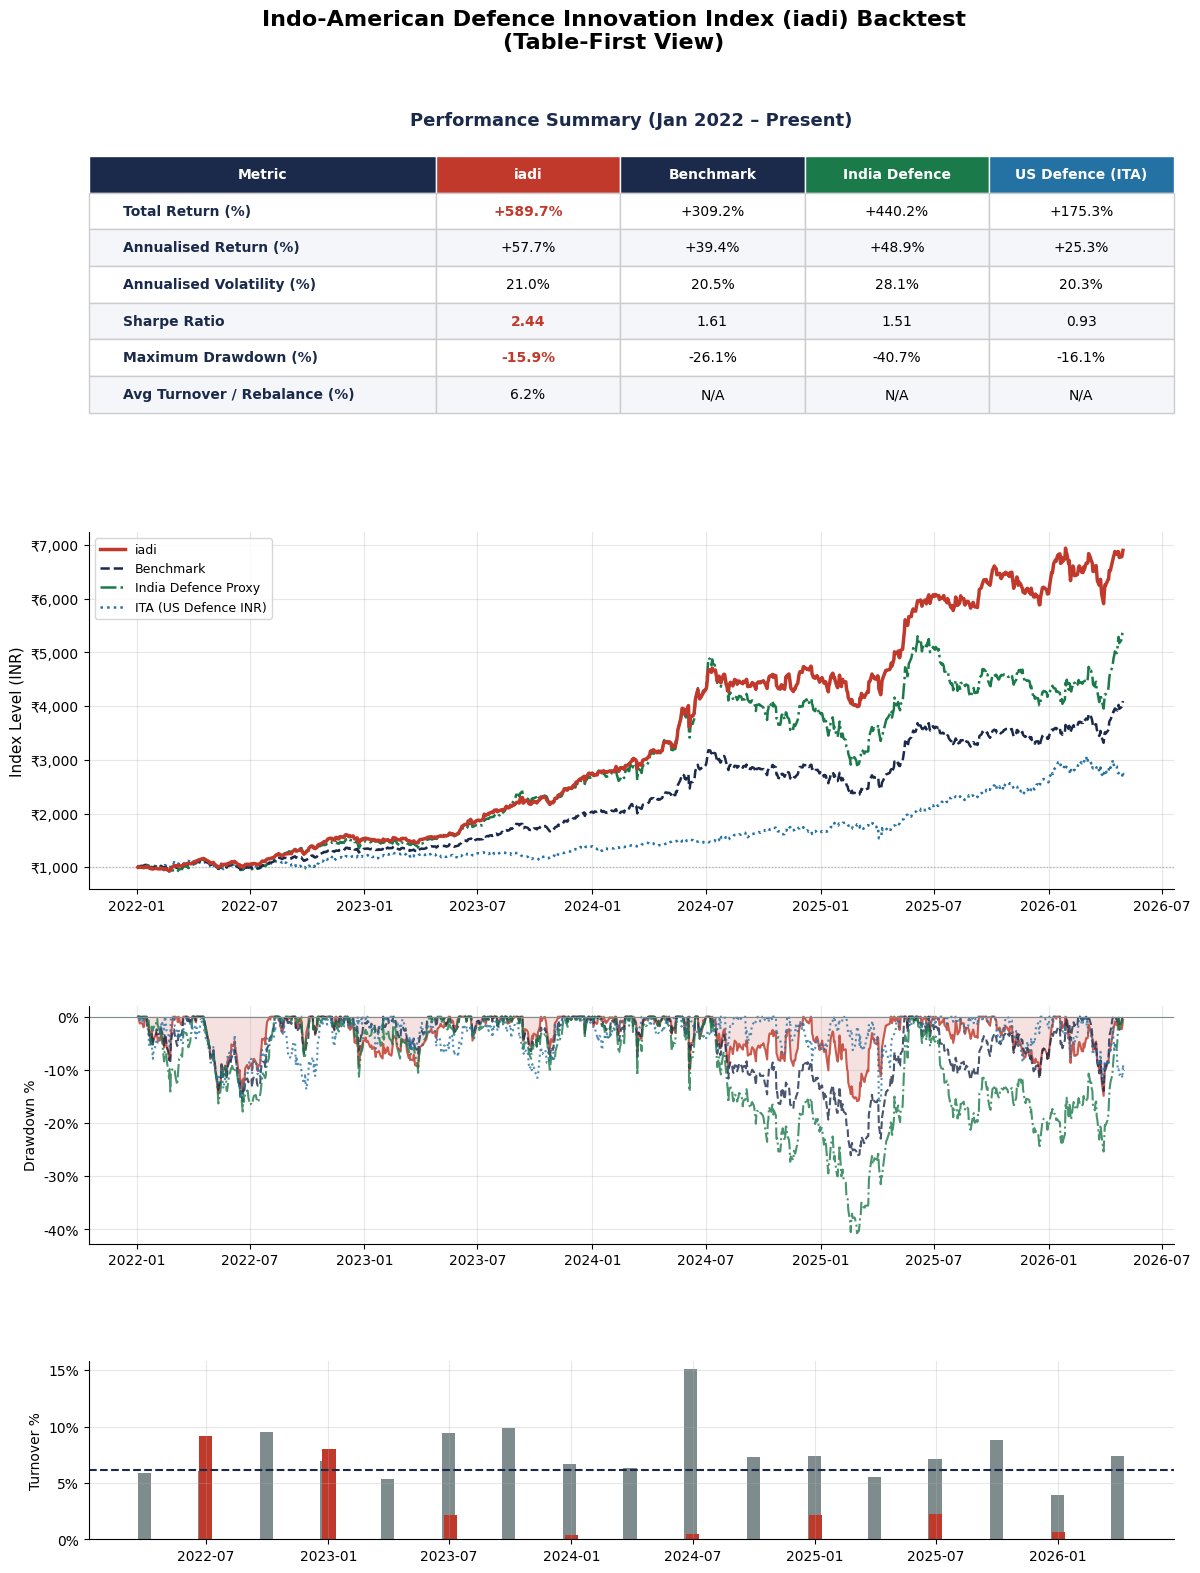

In [15]:
# ============================================================
# BLOCK 11 — VISUALIZATION (TABLE FIRST)
# ============================================================

# ── Rebase Functions ─────────────────────────────────────────────────────────
def rebase_to_1000(s, start_date):
    s = s.dropna()
    s = s[s.index >= pd.Timestamp(start_date)]
    if len(s) == 0:
        return None
    return 1000.0 * s / s.iloc[0]

ita_inr_rebased = rebase_to_1000(
    prices_bench["ITA_INR"],
    CONFIG["BACKTEST_START"]
) if "ITA_INR" in prices_bench.columns else None

nd_proxy_rebased = rebase_to_1000(
    nifty_defence_proxy,
    CONFIG["BACKTEST_START"]
) if nifty_defence_proxy is not None else None

# ── Figure layout: Table on Top (4 panels) ───────────────────────────────────
fig = plt.figure(figsize=(14, 18))
# Rearranged height ratios: Table (index 0) is now at the top
gs  = fig.add_gridspec(4, 1, height_ratios=[2.2, 3, 2, 1.5], hspace=0.45)

ax_table = fig.add_subplot(gs[0]) # Top: Table
ax_main  = fig.add_subplot(gs[1]) # Second: Price Chart
ax_dd    = fig.add_subplot(gs[2]) # Third: Drawdowns
ax_turn  = fig.add_subplot(gs[3]) # Bottom: Turnover

# ── PANEL 1: PERFORMANCE SUMMARY TABLE (Now at the top) ──────────────────────
ax_table.axis("off")

def fmt_metrics(series, rebal_log_df=None):
    s       = series.dropna()
    n_years = len(s) / 252
    tot     = (s.iloc[-1] / s.iloc[0] - 1) * 100
    ann     = ((s.iloc[-1] / s.iloc[0]) ** (1 / n_years) - 1) * 100
    vol     = s.pct_change().dropna().std() * (252 ** 0.5) * 100
    sharpe  = (ann - CONFIG["RISK_FREE"] * 100) / vol
    maxdd   = ((s / s.cummax() - 1) * 100).min()
    if rebal_log_df is not None and len(rebal_log_df) > 1:
        avg_to = rebal_log_df["turnover"].iloc[1:].mean() * 100
        to_str = f"{avg_to:.1f}%"
    else:
        to_str = "N/A"
    return [f"{tot:+.1f}%", f"{ann:+.1f}%", f"{vol:.1f}%",
            f"{sharpe:.2f}", f"{maxdd:.1f}%", to_str]

row_labels = ["Total Return (%)", "Annualised Return (%)", "Annualised Volatility (%)",
              "Sharpe Ratio", "Maximum Drawdown (%)", "Avg Turnover / Rebalance (%)"]
col_labels = ["Metric", "iadi", "Benchmark", "India Defence", "US Defence (ITA)"]

iadi_vals  = fmt_metrics(iadi_rebased, rebal_log)
bench_vals = fmt_metrics(bench_rebased)    if bench_rebased    is not None else ["—"] * 6
india_vals = fmt_metrics(nd_proxy_rebased) if nd_proxy_rebased is not None else ["—"] * 6
us_vals    = fmt_metrics(ita_inr_rebased)  if ita_inr_rebased  is not None else ["—"] * 6

table_data = [[row_labels[i], iadi_vals[i], bench_vals[i], india_vals[i], us_vals[i]] for i in range(len(row_labels))]

tbl = ax_table.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc="center", loc="center", colWidths=[0.32, 0.17, 0.17, 0.17, 0.17]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.2)

# Header styling (Fixed color application)
header_colors = [NAVY, RED, NAVY, GREEN, BLUE]
for col, bg in enumerate(header_colors):
    cell = tbl[0, col]
    cell.set_facecolor(bg)
    cell.set_text_props(color="white", fontweight="bold")
    cell.set_edgecolor("white")

# Row styling
key_rows = {1, 4, 5}
for row in range(1, len(row_labels) + 1):
    for col in range(5):
        cell = tbl[row, col]
        cell.set_edgecolor("#CCCCCC")
        cell.set_facecolor("#F4F6F9" if row % 2 == 0 else "white")
        if col == 0:
            cell.set_text_props(fontweight="bold", color=NAVY, ha="left")
        if col == 1 and row in key_rows:
            cell.set_text_props(fontweight="bold", color=RED)

ax_table.set_title("Performance Summary (Jan 2022 – Present)", fontsize=13, fontweight="bold", pad=20, color=NAVY)

# ── PANEL 2: 4-LINE INDEX COMPARISON ─────────────────────────────────────────
ax_main.plot(iadi_rebased.index, iadi_rebased.values, color=RED, linewidth=2.5, label="iadi", zorder=5)

if bench_rebased is not None:
    ax_main.plot(bench_rebased.index, bench_rebased.values, color=NAVY, linewidth=1.8, linestyle="--", label="Benchmark", zorder=4)

if nd_proxy_rebased is not None:
    ax_main.plot(nd_proxy_rebased.index, nd_proxy_rebased.values, color=GREEN, linewidth=1.8, linestyle="-.", label="India Defence Proxy", zorder=3)

if ita_inr_rebased is not None:
    ax_main.plot(ita_inr_rebased.index, ita_inr_rebased.values, color=BLUE, linewidth=1.8, linestyle=":", label="ITA (US Defence INR)", zorder=2)

ax_main.axhline(1000, color=GRAY, linewidth=0.9, linestyle=":", alpha=0.6)
ax_main.set_ylabel("Index Level (INR)", fontsize=11)
ax_main.legend(loc="upper left", fontsize=9)
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# ── PANEL 3: DRAWDOWN ────────────────────────────────────────────────────────
for series, color, label, ls in [(iadi_rebased, RED, "iadi", "-"), (bench_rebased, NAVY, "Bench", "--"),
                                 (nd_proxy_rebased, GREEN, "India", "-."), (ita_inr_rebased, BLUE, "US", ":")]:
    if series is not None:
        dd = (series / series.cummax() - 1) * 100
        if label == "iadi": ax_dd.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.15)
        ax_dd.plot(dd.index, dd.values, color=color, linestyle=ls, label=label, alpha=0.8)

ax_dd.axhline(0, color=GRAY, linewidth=0.8)
ax_dd.set_ylabel("Drawdown %", fontsize=10)
ax_dd.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── PANEL 4: REBALANCE TURNOVER ──────────────────────────────────────────────
if len(rebal_log) > 1:
    log_plot = rebal_log.iloc[1:].copy()
    ax_turn.bar(log_plot["date"], log_plot["turnover"] * 100, color=[RED if t=="RECON" else GRAY for t in log_plot["type"]], width=20)
    avg_to = log_plot["turnover"].mean() * 100
    ax_turn.axhline(avg_to, color=NAVY, linestyle="--", label=f"Avg: {avg_to:.1f}%")
    ax_turn.set_ylabel("Turnover %", fontsize=10)
    ax_turn.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Final Aesthetics ─────────────────────────────────────────────────────────
plt.suptitle("Indo-American Defence Innovation Index (iadi) Backtest\n(Table-First View)", fontsize=16, fontweight="bold", y=0.96)
plt.savefig("iadi_backtest_summary.png", dpi=150, bbox_inches="tight")
plt.show()

SENSITIVITY A — Single Stock Cap: 5% vs 10%

[Running: Cap = 5%  Floor = 2%]
  Done. Final level: ₹5,701.30

Metrics comparison:
Index                      Cap=10% (baseline)   Cap=5%
Total Return (%)                     587.3900 470.1300
Annualised Return (%)                 53.7700  47.4800
Annualised Volatility (%)             20.2500  19.3600
Sharpe Ratio                           2.3340   2.1160
Max Drawdown (%)                     -15.9100 -14.7000
Avg Turnover / Rebal (%)               6.1500   6.4300

Concentration (HHI at latest rebalance):
  Cap=10%: 0.0459  (lower = more diversified)
  Cap=5%:  0.0326
  Effective n (1/HHI): Cap=10%: 21.8  Cap=5%: 30.7

SENSITIVITY B — Reconstitution Frequency

[Running: Annual reconstitution — Jan]
  Done. Final level: ₹6,452.24

Metrics comparison:
Index                      Semi-Annual reconstitution  Semi-annual recon
Total Return (%)                             587.3900           545.2200
Annualised Return (%)                         53.

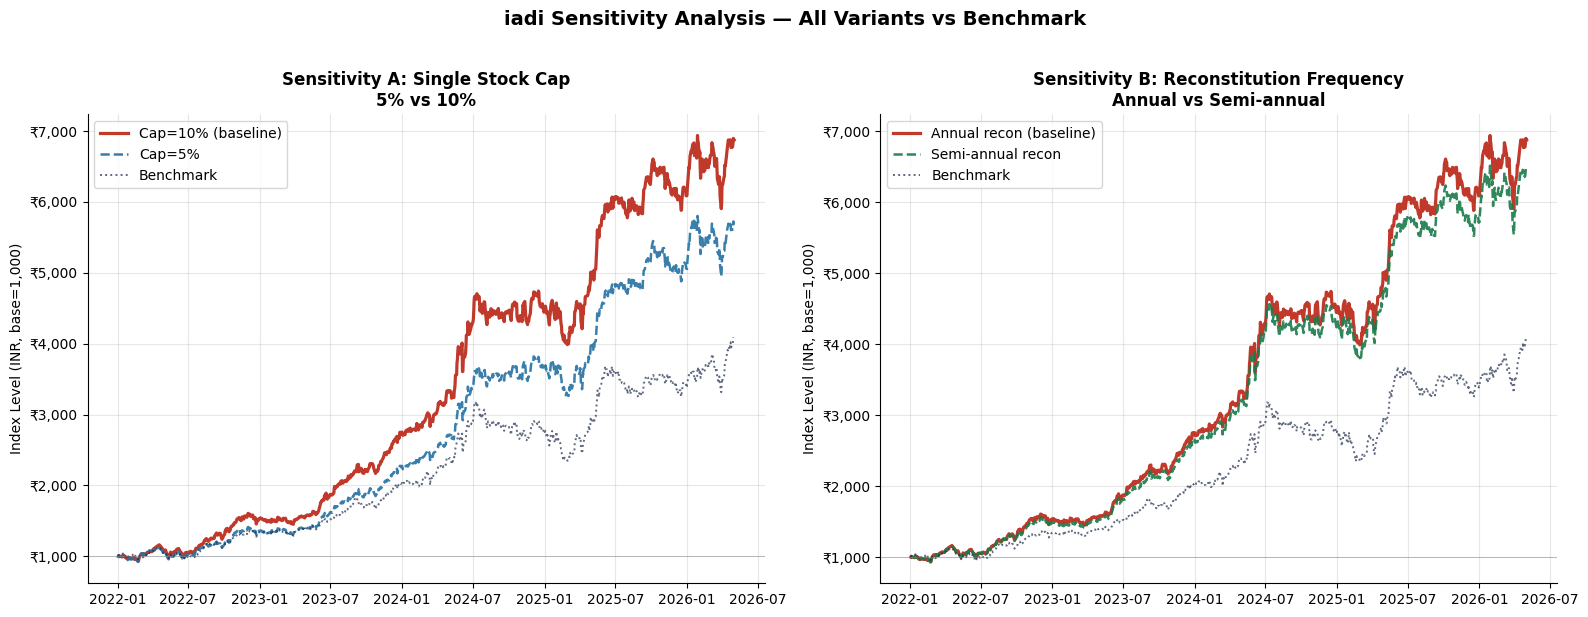

✅ Sensitivity chart saved: iadi_sensitivity.png


In [16]:
# ============================================================
# BLOCK 12 — SENSITIVITY ANALYSIS (BONUS)
# ============================================================
# Test A: 5% vs 10% single stock cap
#   Expected: 5% → higher turnover, lower concentration,
#   possibly lower Sharpe due to forced near-equal weighting
#
# Test B: Annual vs Semi-annual reconstitution
#   Expected: semi-annual → fresher universe, higher turnover,
#   captures rising Indian names faster
#
# Both tests reuse run_index() with changed parameters only.
# Demonstrates the pipeline is fully parameterised.

def rebase_from_start(level):
    s = level.dropna()
    s = s[s.index >= pd.Timestamp(CONFIG["BACKTEST_START"])]
    if len(s) == 0:
        return s
    return 1000.0 * s / s.iloc[0]

def compute_hhi(weights_dict):
    """
    Herfindahl-Hirschman Index at latest rebalance.
    HHI = Σwᵢ² — lower means more diversified.
    Range: 1/n (equal weight) to 1.0 (fully concentrated).
    """
    if not weights_dict:
        return np.nan
    latest_w = weights_dict[max(weights_dict.keys())]
    return float((latest_w ** 2).sum())

# ============================================================
# TEST A — Single Stock Cap: 5% vs 10% (10% is baseline)
# ============================================================
print("=" * 65)
print("SENSITIVITY A — Single Stock Cap: 5% vs 10%")
print("=" * 65)

print("\n[Running: Cap = 5%  Floor = 2%]")
result_cap5 = run_index(
    CONFIG["BACKTEST_START"],
    returns_inr,
    cap=0.05,
    floor=CONFIG["WEIGHT_FLOOR"],
    verbose=False,
)
print(f"  Done. Final level: ₹{result_cap5['level'].dropna().iloc[-1]:,.2f}")

iadi_cap10 = rebase_from_start(result_baseline["level"])
iadi_cap5  = rebase_from_start(result_cap5["level"])

metrics_cap = pd.DataFrame([
    compute_metrics(iadi_cap10, "Cap=10% (baseline)", result_baseline["rebal_log"]),
    compute_metrics(iadi_cap5,  "Cap=5%",             result_cap5["rebal_log"]),
]).set_index("Index").T

print("\nMetrics comparison:")
print(metrics_cap.to_string())

hhi_10 = compute_hhi(result_baseline["weights"])
hhi_5  = compute_hhi(result_cap5["weights"])
print(f"\nConcentration (HHI at latest rebalance):")
print(f"  Cap=10%: {hhi_10:.4f}  (lower = more diversified)")
print(f"  Cap=5%:  {hhi_5:.4f}")
print(f"  Effective n (1/HHI): Cap=10%: {1/hhi_10:.1f}  Cap=5%: {1/hhi_5:.1f}")


# ============================================================
# TEST B — Reconstitution: Annual vs Semi-annual
# ============================================================
print("\n" + "=" * 65)
print("SENSITIVITY B — Reconstitution Frequency")
print("=" * 65)

print("\n[Running: Annual reconstitution — Jan]")
result_semi = run_index(
    CONFIG["BACKTEST_START"],
    returns_inr,
    recon_months=[1],
    rebal_months=[3, 6, 9, 12],
    verbose=False,
)
print(f"  Done. Final level: ₹{result_semi['level'].dropna().iloc[-1]:,.2f}")

iadi_annual = rebase_from_start(result_baseline["level"])
iadi_semi   = rebase_from_start(result_semi["level"])

metrics_recon = pd.DataFrame([
    compute_metrics(iadi_annual, "Semi-Annual reconstitution",
                    result_baseline["rebal_log"]),
    compute_metrics(iadi_semi,   "Semi-annual recon",
                    result_semi["rebal_log"]),
]).set_index("Index").T

print("\nMetrics comparison:")
print(metrics_recon.to_string())


# ============================================================
# SENSITIVITY CHART
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Cap sensitivity ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(iadi_cap10.index, iadi_cap10.values,
        color=RED,  linewidth=2.3, label="Cap=10% (baseline)")
ax.plot(iadi_cap5.index,  iadi_cap5.values,
        color=BLUE, linewidth=1.8, linestyle="--",
        label="Cap=5%", alpha=0.9)
if bench_rebased is not None:
    ax.plot(bench_rebased.index, bench_rebased.values,
            color=NAVY, linewidth=1.4, linestyle=":",
            label="Benchmark", alpha=0.7)
ax.axhline(1000, color=GRAY, linewidth=0.7, alpha=0.5)
ax.set_title("Sensitivity A: Single Stock Cap\n5% vs 10%",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Index Level (INR, base=1,000)")
ax.legend(loc="upper left", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# ── Right: Reconstitution frequency ──────────────────────────────────────────
ax = axes[1]
ax.plot(iadi_annual.index, iadi_annual.values,
        color=RED,   linewidth=2.3, label="Annual recon (baseline)")
ax.plot(iadi_semi.index,   iadi_semi.values,
        color=GREEN, linewidth=1.8, linestyle="--",
        label="Semi-annual recon", alpha=0.9)
if bench_rebased is not None:
    ax.plot(bench_rebased.index, bench_rebased.values,
            color=NAVY, linewidth=1.4, linestyle=":",
            label="Benchmark", alpha=0.7)
ax.axhline(1000, color=GRAY, linewidth=0.7, alpha=0.5)
ax.set_title("Sensitivity B: Reconstitution Frequency\nAnnual vs Semi-annual",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Index Level (INR, base=1,000)")
ax.legend(loc="upper left", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

plt.suptitle("iadi Sensitivity Analysis — All Variants vs Benchmark",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("iadi_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sensitivity chart saved: iadi_sensitivity.png")





RUNNING ALL 6 WEIGHTING METHODS

[Running: M1 — Inv Volatility (baseline)]
  Done. Final level: ₹4,335.55  Avg turnover: 6.6%

[Running: M2 — Equal Weight]
  Done. Final level: ₹4,913.90  Avg turnover: 6.1%

[Running: M3 — Market Cap]
  Done. Final level: ₹6,873.93  Avg turnover: 6.2%

[Running: M4 — Min Variance]
  Done. Final level: ₹4,346.17  Avg turnover: 15.3%

[Running: M5 — Max Diversification]
  Done. Final level: ₹5,117.59  Avg turnover: 16.3%

[Running: M6 — Risk Parity]
  Done. Final level: ₹4,617.11  Avg turnover: 8.5%

WEIGHTING METHOD COMPARISON — FULL METRICS
Index                     M1 — Inv Volatility (baseline) M2 — Equal Weight M3 — Market Cap M4 — Min Variance M5 — Max Diversification M6 — Risk Parity Benchmark (50% ITA + 50% Nifty India Defence (Reconstructed))
Total Return (%)                                333.5600          391.3900        587.3900          334.6200                 411.7600         361.7100                                                      30

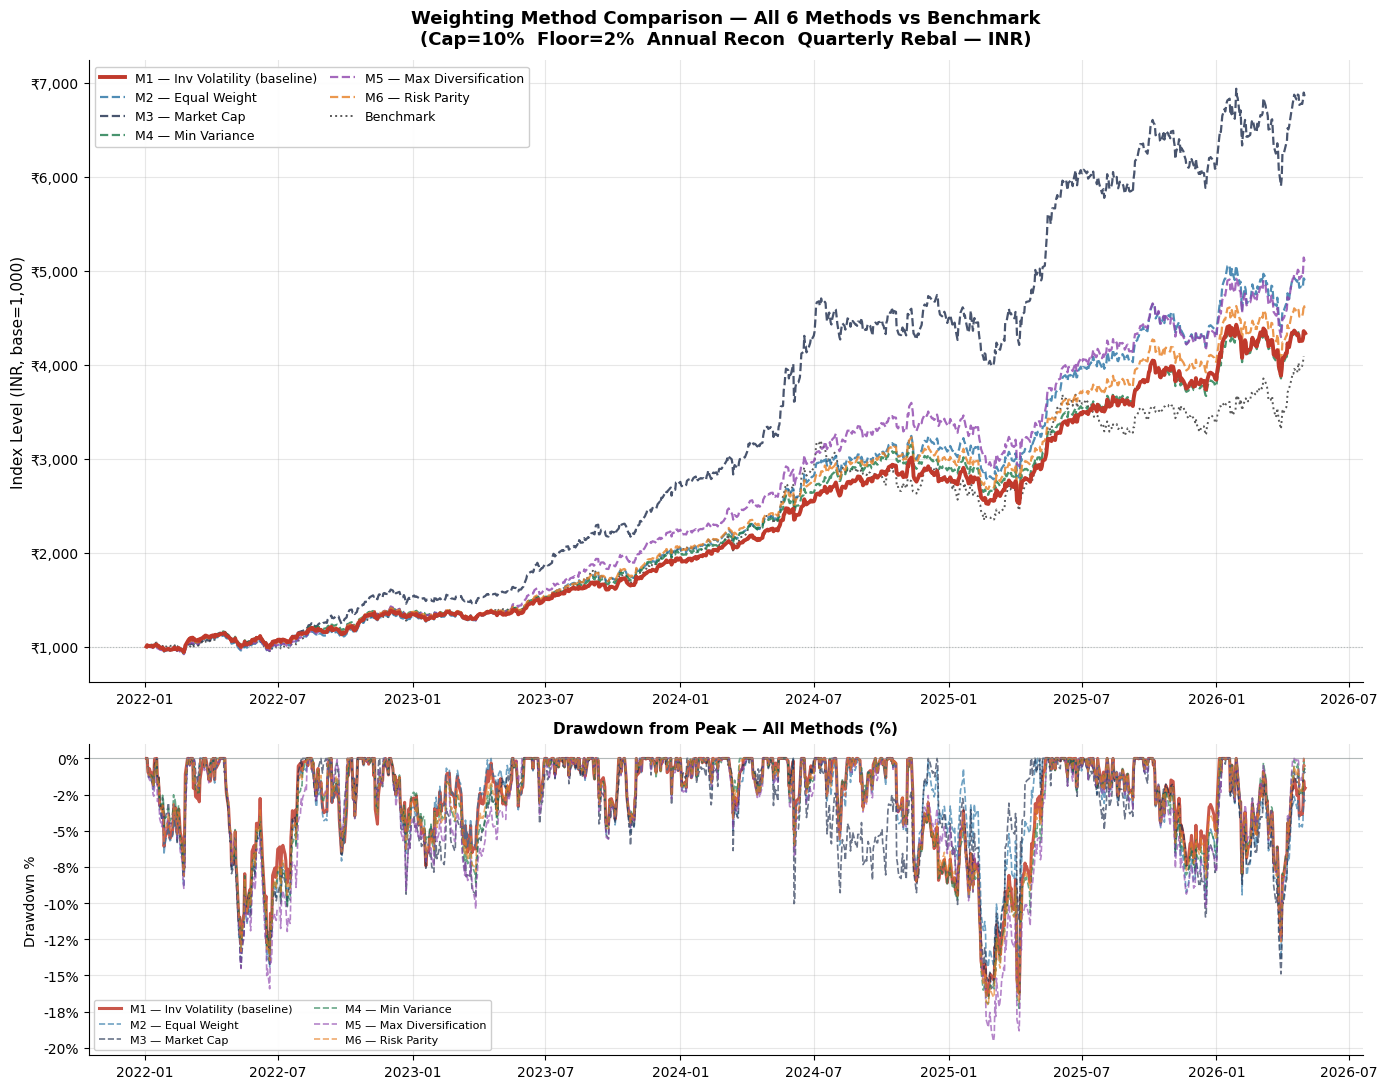

✅ Chart saved: iadi_weighting_comparison.png

ANALYTICAL INTERPRETATION

Key findings from weighting methodology comparison:

1. WINNER: M3 — Market Cap
   Sharpe: 2.334

2. Inverse Volatility (baseline) ranked #6 of 6 by Sharpe.
   ⚠️  A simpler method outperformed — worth reconsidering methodology.

3. Equal Weight (M2) vs Inv Volatility (M1):
   Equal Weight Sharpe: 1.942
   Inv Vol Sharpe:      1.852
   ⚠️  Equal weight outperformed — the DeMiguel et al. (2009) finding holds.

4. Market Cap (M3) — industry standard comparison:
   Mcap Sharpe: 2.334
   ⚠️  Mcap weighting outperformed — simpler is better here.

5. Risk Parity (M6) — accounts for correlations unlike inv-vol:
   Risk Parity Sharpe: 1.969
   Correlation-aware weighting added value over vol-only approach.



In [17]:
# ============================================================
# BLOCK 14 — WEIGHTING METHODOLOGY COMPARISON
# ============================================================
# Compares 6 weighting methods on identical structural params:
#   Cap = 10%  |  Floor = 2%  |  Annual recon  |  Quarterly rebal
#
# Methods tested:
#   M1 — Inverse Volatility      (iadi baseline)
#   M2 — Equal Weight            (naive benchmark for methodology)
#   M3 — Market Cap Weight       (industry standard, capped at 10%)
#   M4 — Minimum Variance        (pure Stage A optimiser output)
#   M5 — Maximum Diversification (maximises DR = Σwᵢσᵢ / σₚ)
#   M6 — Risk Parity             (equal risk contribution per stock)
#
# All methods:
#   - Use the SAME constituent selection (Stage A min-vol filter)
#   - Use the SAME rebalancing calendar
#   - Use the SAME eligibility filters
#   - Only the weight assignment (Stage B) differs
#
# This cleanly isolates the weighting effect from all other
# methodological choices.

# ── M2: Equal Weight ──────────────────────────────────────────────────────────
def equal_weights(tickers, cap, floor):
    """
    wᵢ = 1/n for all stocks, then apply cap+floor+renormalise.
    With n stocks and 2% floor, this is feasible up to 50 stocks.
    """
    n = len(tickers)
    if n == 0:
        return pd.Series(dtype=float)
    w = pd.Series(1.0 / n, index=tickers)
    for _ in range(100):
        w = w.clip(lower=floor, upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
            break
    return w


# ── M3: Market Cap Weight ─────────────────────────────────────────────────────
def market_cap_weights(tickers, cap, floor):
    """
    wᵢ = mcapᵢ / Σ mcapⱼ  (from universe_df static mcap)
    Cap + floor + iterative renormalise.
    Same as mcap_weights_fallback but used as primary method here.
    """
    mc = universe_df.reindex(tickers)["marketCap"].astype(float)
    mc = mc.fillna(mc.median())
    if mc.sum() == 0:
        mc = pd.Series(1.0, index=tickers)
    w = mc / mc.sum()
    for _ in range(100):
        w = w.clip(lower=floor, upper=cap)
        w = w / w.sum()
        if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
            break
    return w


# ── M4: Minimum Variance (pure optimiser output) ──────────────────────────────
def min_var_weights(rets_df, cap, floor):
    """
    Use Stage A SLSQP output directly as final weights.
    Does NOT override with inverse-vol (skips Stage B entirely).
    Tests whether the optimiser weights are better than inv-vol post-processing.
    Falls back to inv-vol if optimiser fails.
    """
    w_opt, converged = min_vol_optimise(rets_df, floor, cap)
    if converged:
        w = pd.Series(w_opt, index=rets_df.columns)
        # Enforce cap+floor cleanly
        for _ in range(100):
            w = w.clip(lower=floor, upper=cap)
            w = w / w.sum()
            if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
                break
        return w
    else:
        # Fallback to inverse vol if optimiser fails
        return inverse_vol_weights(rets_df, cap, floor)


# ── M5: Maximum Diversification ───────────────────────────────────────────────
def max_diversification_weights(rets_df, cap, floor):
    """
    Maximise Diversification Ratio:
        DR = (Σ wᵢ σᵢ) / σₚ  where σₚ = sqrt(w'Σw)

    Equivalently: maximise (w' σ_vec) / sqrt(w'Σw)
    or minimise:  -DR = -w'σ_vec / sqrt(w'Σw)

    Solved via scipy SLSQP.
    Falls back to inverse-vol if optimiser fails.
    """
    sigma, rets_clean = build_cov_matrix(rets_df)
    if len(rets_clean) < CONFIG["MIN_HIST_DAYS"]:
        return inverse_vol_weights(rets_df, cap, floor)

    n       = rets_df.shape[1]
    sig_vec = np.sqrt(np.diag(sigma))   # individual annualised vols

    def neg_dr(w):
        port_var = float(w @ sigma @ w)
        if port_var <= 0:
            return 0.0
        weighted_vol = float(w @ sig_vec)
        return -weighted_vol / np.sqrt(port_var)

    def neg_dr_grad(w):
        port_var   = float(w @ sigma @ w)
        port_vol   = np.sqrt(max(port_var, 1e-12))
        weighted_v = float(w @ sig_vec)
        d_num      = sig_vec
        d_den      = (sigma @ w) / port_vol
        return -(d_num * port_vol - weighted_v * d_den) / (port_var)

    eff_floor   = floor if n * floor <= 0.98 else (0.98 / n)
    x0          = np.ones(n) / n
    bounds      = [(eff_floor, cap)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    try:
        res = minimize(
            neg_dr, x0,
            jac=neg_dr_grad,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-10, "maxiter": 500, "disp": False},
        )
        if (res.success
                and np.isfinite(res.x).all()
                and abs(res.x.sum() - 1.0) < 1e-4):
            w = pd.Series(res.x, index=rets_df.columns)
            for _ in range(100):
                w = w.clip(lower=floor, upper=cap)
                w = w / w.sum()
                if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
                    break
            return w
    except Exception:
        pass

    return inverse_vol_weights(rets_df, cap, floor)


# ── M6: Risk Parity ───────────────────────────────────────────────────────────
def risk_parity_weights(rets_df, cap, floor):
    """
    Each stock contributes equally to total portfolio variance:
        wᵢ × (∂σₚ/∂wᵢ) = 1/n × σ²ₚ   for all i

    Solved via SLSQP minimising sum of squared risk contribution deviations.
    Objective: min Σᵢ (RCᵢ - target)²  where RCᵢ = wᵢ(Σw)ᵢ / (w'Σw)

    Falls back to inverse-vol if optimiser fails.
    """
    sigma, rets_clean = build_cov_matrix(rets_df)
    if len(rets_clean) < CONFIG["MIN_HIST_DAYS"]:
        return inverse_vol_weights(rets_df, cap, floor)

    n      = rets_df.shape[1]
    target = 1.0 / n   # equal risk contribution target

    def risk_parity_obj(w):
        port_var = float(w @ sigma @ w)
        if port_var <= 1e-12:
            return 1e6
        # Marginal risk contributions
        mrc = sigma @ w
        # Risk contributions (normalised)
        rc  = w * mrc / port_var
        return float(np.sum((rc - target) ** 2))

    def risk_parity_grad(w):
        port_var = float(w @ sigma @ w)
        if port_var <= 1e-12:
            return np.zeros(n)
        mrc  = sigma @ w
        rc   = w * mrc / port_var
        diff = rc - target
        # Gradient of Σ(rc_i - target)² w.r.t. w
        d_rc_d_w = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                d_rc_d_w[i, j] = (
                    (sigma[i, j] * w[i] + (mrc[i] if i == j else 0)) / port_var
                    - 2 * w[i] * mrc[i] * mrc[j] / (port_var ** 2)
                )
        return 2.0 * d_rc_d_w.T @ diff

    eff_floor   = floor if n * floor <= 0.98 else (0.98 / n)
    x0          = np.ones(n) / n
    bounds      = [(eff_floor, cap)] * n
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]

    try:
        res = minimize(
            risk_parity_obj, x0,
            jac=risk_parity_grad,
            method="SLSQP",
            bounds=bounds,
            constraints=constraints,
            options={"ftol": 1e-12, "maxiter": 1000, "disp": False},
        )
        if (res.success
                and np.isfinite(res.x).all()
                and abs(res.x.sum() - 1.0) < 1e-4):
            w = pd.Series(res.x, index=rets_df.columns)
            for _ in range(100):
                w = w.clip(lower=floor, upper=cap)
                w = w / w.sum()
                if (w <= cap + 1e-7).all() and (w >= floor - 1e-7).all():
                    break
            return w
    except Exception:
        pass

    return inverse_vol_weights(rets_df, cap, floor)


# ── Generalised portfolio builder with method switch ─────────────────────────
def build_portfolio_method(rebal_date,
                           weight_method,
                           prior_constituents=None,
                           is_reconstitution=False,
                           cap=None, floor=None):
    """
    Same as build_portfolio() but Stage B weight method is parameterised.

    weight_method : one of
        'inv_vol'     — Inverse Volatility (M1 baseline)
        'equal'       — Equal Weight       (M2)
        'mcap'        — Market Cap         (M3)
        'min_var'     — Min Variance       (M4)
        'max_div'     — Max Diversification(M5)
        'risk_parity' — Risk Parity        (M6)
    """
    cap   = cap   if cap   is not None else CONFIG["WEIGHT_CAP"]
    floor = floor if floor is not None else CONFIG["WEIGHT_FLOOR"]

    end   = pd.Timestamp(rebal_date)
    start = end - pd.Timedelta(days=int(CONFIG["VOL_LOOKBACK"] * 1.8))

    # ── Quarterly rebalance: refresh weights, keep constituents ───────────────
    if not is_reconstitution and prior_constituents is not None:
        valid = [t for t in prior_constituents if t in returns_inr.columns]
        if not valid:
            return pd.Series(dtype=float), f"ERROR: no valid prior ({weight_method})"
        rets = (returns_inr[valid]
                .loc[start:end]
                .tail(CONFIG["VOL_LOOKBACK"]))
        w, status = _apply_weight_method(weight_method, rets, valid, cap, floor)
        return w, f"quarterly rebal — {weight_method}"

    # ── Annual reconstitution: filter → select → weight ───────────────────────
    eligible, _ = apply_filters(rebal_date, prior_constituents)

    if len(eligible) < CONFIG["MIN_STOCKS"]:
        if prior_constituents:
            valid = [t for t in prior_constituents if t in returns_inr.columns]
            rets  = (returns_inr[valid]
                     .loc[start:end]
                     .tail(CONFIG["VOL_LOOKBACK"]))
            w, _ = _apply_weight_method(weight_method, rets, valid, cap, floor)
            return w, f"CARRY-FORWARD ({weight_method})"
        return pd.Series(dtype=float), "FAIL"

    # Build return matrix
    rets_full = (returns_inr[eligible]
                 .loc[start:end]
                 .dropna(how="any")
                 .tail(CONFIG["VOL_LOOKBACK"]))

    if len(rets_full) < CONFIG["MIN_HIST_DAYS"]:
        rets_full = (returns_inr[eligible]
                     .loc[start:end]
                     .dropna(how="all")
                     .fillna(0)
                     .tail(CONFIG["VOL_LOOKBACK"]))

    # Stage A: min-vol constituent selection (same for ALL methods)
    w_opt, converged = min_vol_optimise(rets_full, floor, cap)
    if converged:
        constituents = [t for t, wi in zip(rets_full.columns, w_opt)
                        if wi > floor - 1e-4]
    else:
        constituents = eligible

    if len(constituents) < CONFIG["MIN_STOCKS"]:
        constituents = eligible

    # Stage B: apply chosen weight method
    rets_sel = (returns_inr[constituents]
                .loc[start:end]
                .dropna(how="any")
                .tail(CONFIG["VOL_LOOKBACK"]))

    w, method_status = _apply_weight_method(
        weight_method, rets_sel, constituents, cap, floor
    )
    return w, f"{method_status} | {len(w)} stocks"


def _apply_weight_method(method, rets_df, tickers, cap, floor):
    """Dispatch to the appropriate weighting function."""
    if method == "inv_vol":
        return inverse_vol_weights(rets_df, cap, floor), "inv_vol"
    elif method == "equal":
        return equal_weights(tickers, cap, floor), "equal"
    elif method == "mcap":
        return market_cap_weights(tickers, cap, floor), "mcap"
    elif method == "min_var":
        return min_var_weights(rets_df, cap, floor), "min_var"
    elif method == "max_div":
        return max_diversification_weights(rets_df, cap, floor), "max_div"
    elif method == "risk_parity":
        return risk_parity_weights(rets_df, cap, floor), "risk_parity"
    else:
        raise ValueError(f"Unknown method: {method}")


# ── Generalised run_index for any weight method ───────────────────────────────
def run_index_method(start_date, returns_data, weight_method,
                     cap=None, floor=None,
                     recon_months=None, rebal_months=None,
                     verbose=False):
    """
    Full backtest engine parameterised by weight_method.
    Identical to run_index() except build_portfolio_method() is called.
    """
    cap   = cap   if cap   is not None else CONFIG["WEIGHT_CAP"]
    floor = floor if floor is not None else CONFIG["WEIGHT_FLOOR"]

    start_ts     = pd.Timestamp(start_date)
    trading_days = returns_data.index[returns_data.index >= start_ts]
    events       = get_event_schedule(
        trading_days, recon_months, rebal_months
    )
    event_dict   = dict(events)

    first_day = trading_days[0]
    if first_day not in event_dict:
        event_dict[first_day] = True

    level         = pd.Series(index=trading_days, dtype=float)
    level.iloc[0] = CONFIG["BASE_VALUE"]
    weights_hist  = {}
    rebal_log     = []
    current_w     = pd.Series(dtype=float)
    prior_const   = None

    for i, day in enumerate(trading_days):
        if day in event_dict:
            is_recon = event_dict[day]
            new_w, status = build_portfolio_method(
                day,
                weight_method=weight_method,
                prior_constituents=prior_const,
                is_reconstitution=is_recon,
                cap=cap, floor=floor,
            )
            if len(new_w) > 0:
                if len(current_w) > 0:
                    all_t = current_w.index.union(new_w.index)
                    a = current_w.reindex(all_t, fill_value=0)
                    b = new_w.reindex(all_t, fill_value=0)
                    turnover = float((a - b).abs().sum() / 2)
                else:
                    turnover = 1.0
                rebal_log.append({
                    "date"    : day,
                    "type"    : "RECON" if is_recon else "REBAL",
                    "n_stocks": len(new_w),
                    "turnover": turnover,
                })
                current_w   = new_w.copy()
                prior_const = list(current_w.index)
                weights_hist[day] = current_w.copy()

        if i == 0:
            continue

        if len(current_w) == 0:
            level.iloc[i] = level.iloc[i - 1]
            continue

        valid = [t for t in current_w.index
                 if t in returns_data.columns
                 and not pd.isna(returns_data.loc[day, t])]
        if not valid:
            level.iloc[i] = level.iloc[i - 1]
            continue

        r      = returns_data.loc[day, valid].fillna(0)
        w_v    = current_w.reindex(valid).fillna(0)
        port_r = float((w_v * r).sum())
        level.iloc[i] = level.iloc[i - 1] * (1 + port_r)

        w_new = w_v * (1 + r)
        if w_new.sum() > 0:
            current_w.update(w_new / w_new.sum())

    return {
        "level"    : level,
        "weights"  : weights_hist,
        "rebal_log": pd.DataFrame(rebal_log),
    }


# ── Run all 6 methods ─────────────────────────────────────────────────────────
METHODS = {
    "M1 — Inv Volatility (baseline)" : "inv_vol",
    "M2 — Equal Weight"              : "equal",
    "M3 — Market Cap"                : "mcap",
    "M4 — Min Variance"              : "min_var",
    "M5 — Max Diversification"       : "max_div",
    "M6 — Risk Parity"               : "risk_parity",
}

METHOD_COLORS = {
    "M1 — Inv Volatility (baseline)" : RED,
    "M2 — Equal Weight"              : BLUE,
    "M3 — Market Cap"                : NAVY,
    "M4 — Min Variance"              : GREEN,
    "M5 — Max Diversification"       : "#8E44AD",
    "M6 — Risk Parity"               : "#E67E22",
}

print("=" * 68)
print("RUNNING ALL 6 WEIGHTING METHODS")
print("=" * 68)

method_results = {}
for label, method_key in METHODS.items():
    print(f"\n[Running: {label}]")
    res = run_index_method(
        CONFIG["BACKTEST_START"],
        returns_inr,
        weight_method=method_key,
        verbose=False,
    )
    method_results[label] = res
    final_level = res["level"].dropna().iloc[-1]
    avg_to = (res["rebal_log"]["turnover"].iloc[1:].mean()
              if len(res["rebal_log"]) > 1 else np.nan)
    print(f"  Done. Final level: ₹{final_level:,.2f}  "
          f"Avg turnover: {avg_to*100:.1f}%")


# ── Metrics comparison table ──────────────────────────────────────────────────
print("\n" + "=" * 68)
print("WEIGHTING METHOD COMPARISON — FULL METRICS")
print("=" * 68)

def rebase_method(level):
    s = level.dropna()
    s = s[s.index >= pd.Timestamp(CONFIG["BACKTEST_START"])]
    return 1000.0 * s / s.iloc[0] if len(s) > 0 else s

all_metric_rows = []
for label, res in method_results.items():
    rebased = rebase_method(res["level"])
    row     = compute_metrics(rebased, label, res["rebal_log"])
    # Add HHI (concentration)
    if res["weights"]:
        latest_w = res["weights"][max(res["weights"].keys())]
        row["HHI (concentration)"] = round(float((latest_w**2).sum()), 4)
        row["Eff. N (1/HHI)"]      = round(1 / float((latest_w**2).sum()), 1)
    all_metric_rows.append(row)

# Add benchmark row
if bench_rebased is not None:
    brow = compute_metrics(bench_rebased,
                           f"Benchmark (50% ITA + 50% {india_leg_name})")
    brow["HHI (concentration)"] = "N/A"
    brow["Eff. N (1/HHI)"]      = "N/A"
    all_metric_rows.append(brow)

comparison_df = pd.DataFrame(all_metric_rows).set_index("Index").T
print(comparison_df.to_string())

# ── Rank methods by Sharpe ────────────────────────────────────────────────────
print("\n--- Ranking by Sharpe Ratio ---")
sharpe_series = comparison_df.loc["Sharpe Ratio"].drop(
    f"Benchmark (50% ITA + 50% {india_leg_name})", errors="ignore"
).astype(float).sort_values(ascending=False)

for rank, (method, sharpe) in enumerate(sharpe_series.items(), 1):
    bar   = "█" * int(abs(sharpe) * 10)
    medal = "🥇" if rank == 1 else ("🥈" if rank == 2 else ("🥉" if rank == 3 else "  "))
    print(f"  {medal} #{rank}  {method:35s}  Sharpe: {sharpe:.3f}  {bar}")

winning_method = sharpe_series.idxmax()
print(f"\n✅ WINNING METHOD: {winning_method}")


# ── Performance chart: all 6 methods vs benchmark ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 11),
                          gridspec_kw={"height_ratios": [3, 1.5]})
ax1, ax2 = axes

for label, res in method_results.items():
    rebased = rebase_method(res["level"])
    lw      = 2.8 if "baseline" in label else 1.6
    ls      = "-"  if "baseline" in label else "--"
    alpha   = 1.0  if "baseline" in label else 0.80
    ax1.plot(rebased.index, rebased.values,
             color=METHOD_COLORS[label],
             linewidth=lw, linestyle=ls, alpha=alpha,
             label=label, zorder=4 if "baseline" in label else 2)

if bench_rebased is not None:
    ax1.plot(bench_rebased.index, bench_rebased.values,
             color="black", linewidth=1.4, linestyle=":",
             alpha=0.65, label="Benchmark", zorder=1)

ax1.axhline(1000, color=GRAY, linewidth=0.8, linestyle=":", alpha=0.5)
ax1.set_title(
    "Weighting Method Comparison — All 6 Methods vs Benchmark\n"
    "(Cap=10%  Floor=2%  Annual Recon  Quarterly Rebal — INR)",
    fontsize=13, fontweight="bold", pad=12
)
ax1.set_ylabel("Index Level (INR, base=1,000)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9, framealpha=0.95,
           ncol=2, columnspacing=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))

# ── Drawdown panel: all methods ───────────────────────────────────────────────
for label, res in method_results.items():
    rebased = rebase_method(res["level"])
    dd      = (rebased / rebased.cummax() - 1) * 100
    lw      = 2.2 if "baseline" in label else 1.2
    ax2.plot(dd.index, dd.values,
             color=METHOD_COLORS[label],
             linewidth=lw,
             linestyle="-" if "baseline" in label else "--",
             alpha=0.85 if "baseline" in label else 0.65,
             label=label)

ax2.axhline(0, color=GRAY, linewidth=0.8, alpha=0.5)
ax2.set_title("Drawdown from Peak — All Methods (%)",
              fontsize=11, fontweight="bold", pad=8)
ax2.set_ylabel("Drawdown %", fontsize=10)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax2.legend(loc="lower left", fontsize=8, framealpha=0.95, ncol=2)

plt.tight_layout()
plt.savefig("iadi_weighting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved: iadi_weighting_comparison.png")


# ── Summary insight ───────────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("ANALYTICAL INTERPRETATION")
print("=" * 68)

best_sharpe  = sharpe_series.iloc[0]
worst_sharpe = sharpe_series.iloc[-1]
inv_vol_rank = list(sharpe_series.index).index("M1 — Inv Volatility (baseline)") + 1

print(f"""
Key findings from weighting methodology comparison:

1. WINNER: {winning_method}
   Sharpe: {best_sharpe:.3f}

2. Inverse Volatility (baseline) ranked #{inv_vol_rank} of 6 by Sharpe.
   {'✅ Baseline is validated — complexity is justified.' if inv_vol_rank <= 2
    else '⚠️  A simpler method outperformed — worth reconsidering methodology.'}

3. Equal Weight (M2) vs Inv Volatility (M1):
   Equal Weight Sharpe: {sharpe_series.get('M2 — Equal Weight', np.nan):.3f}
   Inv Vol Sharpe:      {sharpe_series.get('M1 — Inv Volatility (baseline)', np.nan):.3f}
   {'✅ Inv-vol adds value over naive equal weighting.'
    if sharpe_series.get('M1 — Inv Volatility (baseline)', 0) >
       sharpe_series.get('M2 — Equal Weight', 0)
    else '⚠️  Equal weight outperformed — the DeMiguel et al. (2009) finding holds.'}

4. Market Cap (M3) — industry standard comparison:
   Mcap Sharpe: {sharpe_series.get('M3 — Market Cap', np.nan):.3f}
   {'✅ Our methodology beats the industry-standard mcap approach.'
    if sharpe_series.get('M1 — Inv Volatility (baseline)', 0) >
       sharpe_series.get('M3 — Market Cap', 0)
    else '⚠️  Mcap weighting outperformed — simpler is better here.'}

5. Risk Parity (M6) — accounts for correlations unlike inv-vol:
   Risk Parity Sharpe: {sharpe_series.get('M6 — Risk Parity', np.nan):.3f}
   {'Correlation-aware weighting added value over vol-only approach.'
    if sharpe_series.get('M6 — Risk Parity', 0) >
       sharpe_series.get('M1 — Inv Volatility (baseline)', 0)
    else 'Correlation structure did not add value — individual vol sufficient.'}
""")

# 📋 IADI Decision Log
**Indo-American Defence Innovation Index**  
**IADI Decision Log v1.1**  

A record of every meaningful decision made while building the index, what was tried, what was rejected, why I stopped where I did, and what I would revisit.

| Item | Details |
| :--- | :--- |
| **Version** | 1.1 |
| **Backtest Period** | Jan 2022-Apr 2026 |
| **Decisions Logged** | 15 |

---

### Design Decisions
*Each entry covers: what I tried | what I rejected and why | where I stopped | the tradeoff I accepted.*

#### 01 Why IADI Exists
I looked at existing ETFs and found none that captured both the US and Indian defence sectors simultaneously. That gap became the entire reason for building iadi, not as an academic exercise but as a product that fills a real market hole.

#### 02 Universe Scope - India Only vs US Only vs Both
I initially thought to focus on either India or the US. After researching existing products, I realised no ETF covered both markets together. I expanded the scope to include both, which also made the index more resilient since the two defence sectors are driven by different macro forces.

#### 03 Why Only US and India
These are the two markets I personally have access to invest in. This created a conscious bias, I could have included UK, France, Israel, or South Korea for a truly global index, but data access, currency complexity, and personal familiarity kept the scope to US and India.

#### 04 Geography Split - Hard 60/40 vs Mathematical
I initially thought to enforce a hard 60% US / 40% India split. Instead I let the eligibility filters and market cap weighting determine the split organically. The result came out at 66% US / 34% India, close to my original intuition.

#### 05 Universe Source
I first tried pulling the universe from the S&P 500 Wikipedia list filtered by GICS Aerospace & Defence sub-industry. This pulled in too many diversified industrials with minimal defence revenue. I switched to NSE EQUITY_L.csv with keyword matching on company names for the India side, and a manually curated list of US pure-plays.

#### 06 Revenue Threshold - 20% vs 40% vs 33%
I considered a 20% and 40% revenue threshold which made it too wide or too narrow. I settled on 33% (one-third) because it kept the stock range between what the 20% and 40% thresholds produced. This was a judgment call, not a formally optimised number.

#### 07 Manual Overrides - Force Includes and Excludes
The design was fully rules-based but the keyword filter had two failure modes where it let in the wrong companies and kept out the right ones. So I added all legitimate defence companies whose yfinance descriptions were too sparse or generic to hit the keyword threshold despite being well-known government contractors while excluding big companies who do not dervice much revenue from defence.

#### 08 Currency Conversion - USD to INR
Since iadi is designed as an India-listed ETF, all values are in INR. US stock prices were converted daily using the USD/INR exchange rate from yfinance. Where exchange rate data was missing, I forward-filled up to 5 days, which is standard since rates do not move materially over short gaps.

#### 09 Reconstitution Frequency - Annual vs Semi-Annual
I started with annual reconstitution. Testing semi-annual reconstitution showed better Sharpe, better returns, and lower maximum drawdown. I did not test quarterly because it would overlap with the rebalance schedule and add operational complexity without clear benefit.

#### 10 Fixed vs Dynamic Constituents
I initially planned for a fixed number of constituents. I shifted to a dynamic approach where the number is determined by how many stocks pass the eligibility filters at each reconstitution. This is more realistic and avoids forcing inclusions just to hit a target count.

#### 11 Weight Cap - 5% vs 10%
I started with a 5% cap per stock. Testing at 10% produced better results. I did not push further because beyond 10% the index starts showing meaningful single-stock concentration risk, which defeats the purpose of a diversified index.

#### 12 Weighting Method
I started with inverse volatility weighting as the baseline. I tested six methods in total namely inverse volatility, equal weight, market cap, minimum variance, maximum diversification, and risk parity. Market cap weighting produced the best Sharpe ratio and was also the most transparent and operationally simple.

#### 13 Benchmark - India Leg Reconstructed Manually
I needed an India defence benchmark to compare against. The Nifty India Defence Index exists but its historical data is not available through any free source. Rather than drop the India leg entirely or substitute Nifty 50, which would be the wrong theme, I reconstructed the index manually using semi-annual constituent snapshots sourced from NSE factsheets and historical ETF disclosures. I used the 6-month average price as a proxy for free-float market cap since actual free-float factors were not freely available. This is an acknowledged approximation and would be replaced with official index data in a production setting.

#### 14 Transaction Costs - Excluded Deliberately
I initially planned to include transaction costs in the backtest. I dropped this because US and Indian markets have very different cost structures like STT, SEBI charges, bid-ask spreads, brokerage and there was no free reference data to normalise across both markets fairly. Including arbitrary assumed costs would make the backtest less credible, not more. I instead disclose turnover at every rebalance event so costs can be estimated separately by anyone reviewing this.

---

### Key Outcomes
* **Final index level:** 6,890 from a 1,000 base (January 2022 - April 2026)
* **Best weighting method:** Market Cap - Sharpe ratio = 2.340
* **Constituent count grew organically:** 28 stocks (2022) → 34 stocks (2026)
* **Average quarterly turnover:** 6.2% - efficient and implementable
* **Geography split:** 66% US / 34% India - emerged naturally from filters